### Задание 2
Чем активнее наши пользователи – тем выше нагрузка на сервера. И в последнее время нам всё чаще приходят жалобы, что приложение подвисает. <br>
Необходимо спрогнозировать, как изменится активность пользователей в течение ближайшего месяца.

#### 1) Выберите основную метрику, которую вы планируете прогнозировать. Обоснуйте, почему именно она. Какое временное разрешение вы возьмёте? Будут ли какие-то дополнительные регрессоры, которые вы включите в модель?

На нагрузку на сервера влияет как количество пользователей, так и количество их действий. В связи с этим, для оценки нагрузки на сервера **в качестве целевой метрики** была выбрана суммарная активность пользователей, определяемая как **общая сумма просмотров и лайков**. Это удобно, потому что оба действия напрямую связаны с пользовательскими запросами к системе: просмотры отражают частоту обращений к контенту, а лайки — объем интерактивных операций. В совокупности метрика лучше описывает общий поток действий, чем DAU, поскольку учитывает не только число активных пользователей, но и интенсивность их поведения, так как всего один уникальный пользователь может сгенерировать сразу много просмотров и лайков за день. Также, такая метрика хорошо подходит для прогноза, потому что она агрегирует пользовательское поведение в один показатель, который можно моделировать во времени и сравнивать между днями. Это особенно полезно, если цель — заранее понять пики нагрузки и подготовить инфраструктуру. <br>
Временное разрешение,на мой взгляд, лучше брать почасовое, так как во-первых, у нас имеется внутрисуточная сезонность, что может быть важным для прогноза. <br>
**В качестве регрессора можно рассмотреть DAU**, так как количество действий связано к количеством пользователей в сервисе. В качестве бинарного регрессора возьмём наличие/отсутствие флешмоба.

#### 2) Постройте модель и провалидируйте её. Хватает ли у нас данных для бэктестинга с текущей задачей? Если нет, то определите, для какого горизонта прогнозирования у нас хватает данных.

In [2]:
import orbit #общий пакет
from orbit.models import DLT #один из вариантов модели
from orbit.diagnostics.plot import plot_predicted_data, plot_predicted_components #для рисования предсказаний

#общие штуки для кручения данных
import pandas as pd
import pandahouse as ph
import numpy as np
import os

#общие штуки для рисования
import seaborn as sns
import matplotlib.pyplot as plt
import arviz as az #это полезно для визуализации MCMC

In [3]:
#коннект к базе данных

connection = {'host': 'http://clickhouse.lab.karpov.courses:8123',
                      'database':'simulator_20260320',
                      'user':'student', 
                      'password':'dpo_python_2020'
                     }

Получим необходимые данные

In [53]:
query = '''
SELECT 
    toStartOfHour(time) hour_time,
    count(action) as activity,
    uniqExact(user_id) AS DAU,
    countIf(action = 'like')/countIf(action = 'view') CTR
FROM 
    {db}.feed_actions
WHERE toDate(time)<='2026-04-30'
GROUP BY hour_time
ORDER BY hour_time
'''
activity = ph.read_clickhouse(query=query, connection=connection)
activity.head()

,hour_time,activity,DAU,CTR
0,2026-01-31 00:00:00,22,14,0.466667
1,2026-01-31 01:00:00,32,26,0.142857
2,2026-01-31 02:00:00,24,16,0.263158
3,2026-01-31 03:00:00,11,11,0.000000
4,2026-01-31 04:00:00,18,14,0.125000


<Axes: xlabel='hour_time', ylabel='activity'>

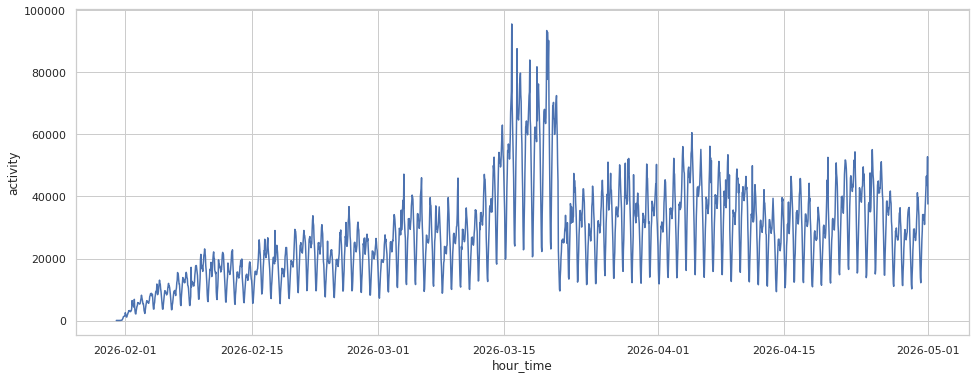

In [54]:
#зададим рисовательный шаблон для сиборна
sns.set(rc={'figure.figsize':(16,6)}, style="whitegrid")
#как менялась активность
sns.lineplot(x=activity.hour_time, y="activity", data=activity)

На данном графике видно, что в целом показатель активности имеет глобальный небольшой возрастающий тренд. Для данных характерна дневная сезонность, что хорошо заметно по пикам. Также заметны локальные изменения- резкое увеличение активности, совпадающие в дни проведения флешмоба с 2026-03-13 по 2026-03-19. Для улучшения прогнозирования необходимо отметить данные выделяющиеся аномальные дни.

<Axes: xlabel='hour_time', ylabel='DAU'>

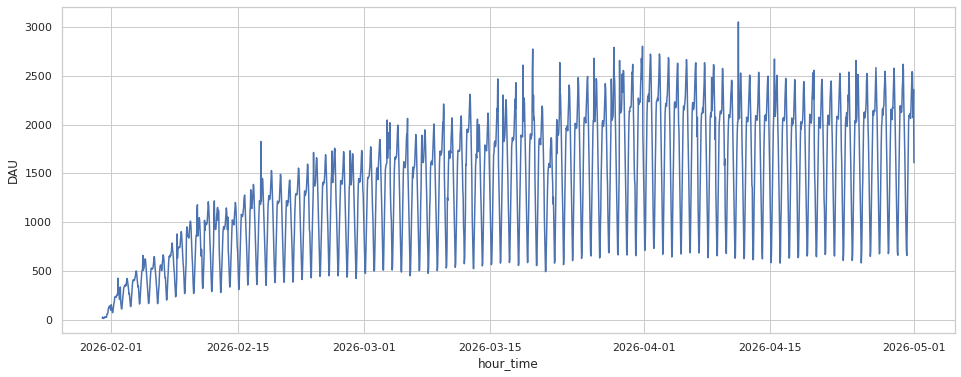

In [55]:
#зададим рисовательный шаблон для сиборна
sns.set(rc={'figure.figsize':(16,6)}, style="whitegrid")
#как менялась DAU
sns.lineplot(x="hour_time", y="DAU", data=activity)

DAU также имеет небольшой возрастающий тренд

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

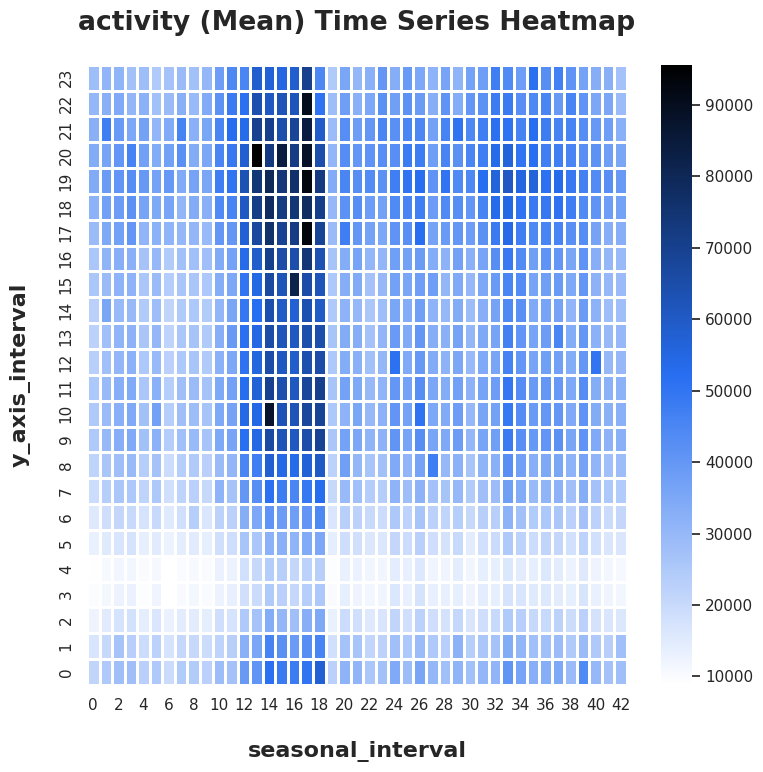

In [8]:
#эксплораторные штуки
from orbit.eda import eda_plot
#тепловая карта
_ = eda_plot.ts_heatmap(df=activity[activity['hour_time']>='2026-03-02 00:00:00'], date_col="hour_time", value_col="activity", seasonal_interval=24, normalization=False)

На графике выше по оси y отображены часы(время суток), по оси х- день от начала данных(в нашем случае точкой отсчёта было выбано 2 марта 2026г). На тепловой карте хорошо видно увеличение активности пользователей в марте, которое приходится на даты проведения флешмоба (более темные клетки, приходящиеся на 12-18 день от начала отсчёта- то есть, примерно на 14-20 числа-дни проведения флешмоба). Внутри дневного промежутка активность, в целом, равномерна распределена, однако самая маленькая активность отмечена примерно с 2 до 5 часов утра, а самая высокая в сутки- в вечернее время, с 18 до 21 часов. Это подтвердается на хитмапе  с нормализацией ниже 

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

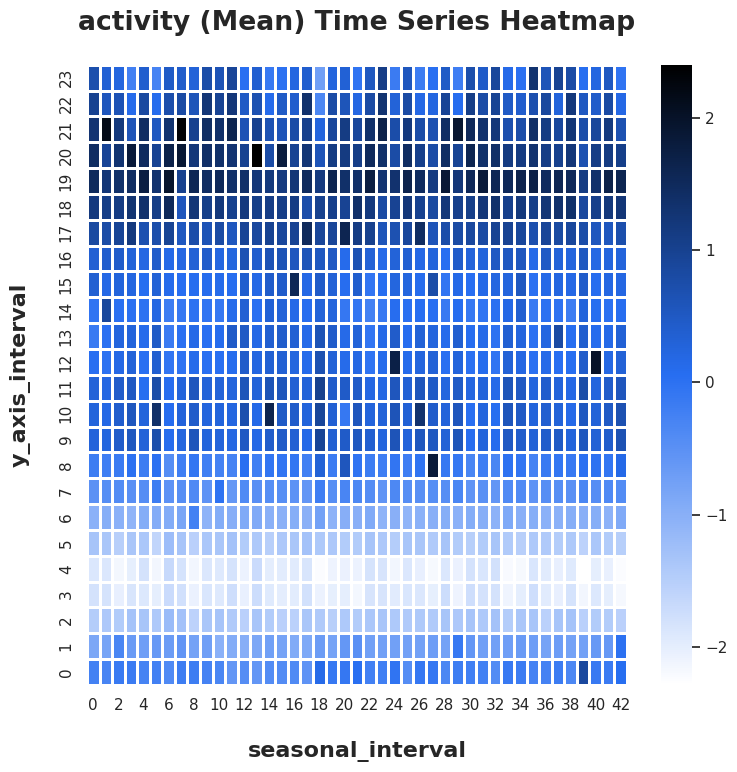

In [9]:
# с нормализацией
_ = eda_plot.ts_heatmap(df=activity[activity['hour_time']>='2026-03-02 00:00:00'], date_col="hour_time", value_col="activity", seasonal_interval=24, normalization=True)

В качестве регрессоров возьмём DAU и наличие флешмоба, то есть даты с 2026-01-13 до 2026-03-20. DAU уже рассчитан, осталось отметить аномалии.

In [56]:
activity['is_flashmob']=np.where((activity.hour_time >= "2026-03-13 00:00:00") & (activity.hour_time <= "2026-03-20"),1,0)
activity.head()

,hour_time,activity,DAU,CTR,is_flashmob
0,2026-01-31 00:00:00,22,14,0.466667,0
1,2026-01-31 01:00:00,32,26,0.142857,0
2,2026-01-31 02:00:00,24,16,0.263158,0
3,2026-01-31 03:00:00,11,11,0.000000,0
4,2026-01-31 04:00:00,18,14,0.125000,0


In [57]:
# модели машинного обучения работают лучше со стандартизованными величинами, то есть, когда среднее = 0, а стандартное отклонение = 1. Стандартизуем метрики.
activity_mean = activity.activity.mean()
activity_sd = activity.activity.std()

dau_mean = activity.DAU.mean()
dau_sd = activity.DAU.std()

activity["DAU_stand"] = (activity.DAU - dau_mean) / dau_sd
activity["activity_stand"] = (activity.activity - activity_mean) / activity_sd
activity.head()

,hour_time,activity,DAU,CTR,is_flashmob,DAU_stand,activity_stand
0,2026-01-31 00:00:00,22,14,0.466667,0,-2.061034,-1.838120
1,2026-01-31 01:00:00,32,26,0.142857,0,-2.042949,-1.837451
2,2026-01-31 02:00:00,24,16,0.263158,0,-2.058020,-1.837986
3,2026-01-31 03:00:00,11,11,0.000000,0,-2.065555,-1.838856
4,2026-01-31 04:00:00,18,14,0.125000,0,-2.061034,-1.838388


#### Построим модели

1. Модель DLT с алгоритмом MAP с линейным трендом
2. Модель DLT с алгоритмом MAP с логлинейным трендом
3. Модель DLT с алгоритмом Марковских цепей Монте-Карло
4. Модель с алгоритмом MAP с линейным трендом + DAU как регрессор
5. Модель с алгоритмом MAP с логлинейным трендом + DAU как регрессор
6. Модель с алгоритмом MAP с линейным трендом + DAU + аномалия
7. Модель с алгоритмом MAP с логлинейный трендом + DAU + аномалия

In [28]:
dlt_linear = DLT(response_col="activity_stand", #название колонки с метрикой
              date_col="hour_time", #название колонки с датами-временем
              seasonality=24, #длина периода сезонности
              estimator="stan-map", #алгоритм оценки
              n_bootstrap_draws=1000) #количество сэмплов бутстрапа для доверительного интервала

dlt_loglinear = DLT(response_col="activity_stand", #название колонки с метрикой
          date_col="hour_time", #название колонки с датами-временем
          seasonality=24, #длина периода сезонности
          estimator="stan-map", #алгоритм оценки
          n_bootstrap_draws=1000, #количество сэмплов бутстрапа для доверительного интервала
          global_trend_option='loglinear') #логлинейный тренд

dlt_mcmc = DLT(seasonality=24, 
               response_col="activity_stand", 
               date_col="hour_time", 
               estimator='stan-mcmc', #новый алгоритм оценки
               num_warmup=2000, #время "разогрева"
               num_sample=1000) #время сэмплирования

dau_linear = DLT(response_col="activity_stand", 
            date_col="hour_time",
            seasonality=24,
            estimator="stan-map",
            n_bootstrap_draws=1000,
            global_trend_option="linear", 
            regressor_col=["DAU_stand"], regressor_sign=["+"])

dau_loglinear = DLT(response_col="activity_stand", 
               date_col="hour_time", 
               seasonality=24,
               estimator="stan-map", 
               n_bootstrap_draws=1000,
               global_trend_option="loglinear",
               regressor_col=["DAU_stand"], regressor_sign=["+"])

anomaly_linear = DLT(response_col="activity_stand", 
            date_col="hour_time",
            seasonality=24,
            estimator="stan-map", 
            n_bootstrap_draws=1000,
            global_trend_option="linear", 
            regressor_col=["DAU_stand", "is_flashmob"], regressor_sign=["+", "+"])

anomaly_loglinear = DLT(response_col="activity_stand", 
               date_col="hour_time", 
               seasonality=24,
               estimator="stan-map",
               n_bootstrap_draws=1000,
               global_trend_option="loglinear",
               regressor_col=["DAU_stand", "is_flashmob"], regressor_sign=["+", "+"])

2026-05-30 19:08:41 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-05-30 19:08:41 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-05-30 19:08:41 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-05-30 19:08:41 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-05-30 19:08:41 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-05-30 19:08:41 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.


Обучаем.
Разделим данные на тренировочную и тестовую часть. Обучать будем на тренировочной части, предсказывать-тестовую, а на графиках оценивать соответствие предсказнанных занчений реальным.

In [58]:
train_dat = activity.query("hour_time > '2026-02-01 00:00:00' & hour_time < '2026-03-30 00:00:00'") #возьмём часть данных для обучения. Взяла 2 месяца для обучения.
test_dat = activity.query("hour_time >= '2026-03-30 00:00:00'").astype({"DAU_stand":"int64"}) #а это будем предсказывать - важно сконвертировать в инт. Предскажем 1 месяц.

In [59]:
models_list = [dlt_linear, dlt_loglinear, dlt_mcmc, dau_linear, dau_loglinear, anomaly_linear, anomaly_loglinear] #создадим список с моделями
for model in models_list:
    model.fit(train_dat)

2026-05-30 20:09:19 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [30]:
#создадим датафрейм с горизонтом прогнозирования. 30 дней, хотим предсказать на будущий месяц.
future_df = dlt_linear.make_future_df(periods=24*30) #горизонт будет 30 дней - то есть 30 раз по 24 часа
future_df.head()

,hour_time
0,2026-04-14 00:00:00
1,2026-04-14 01:00:00
2,2026-04-14 02:00:00
3,2026-04-14 03:00:00
4,2026-04-14 04:00:00


#### Делаем прогноз с помощью моделей dlt_linear и dlt_loglinear

In [62]:
#делаем прогноз для первых двух моделей
predicted_df_1 = dlt_linear.predict(df=test_dat)
predicted_df_2 = dlt_loglinear.predict(df=test_dat)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

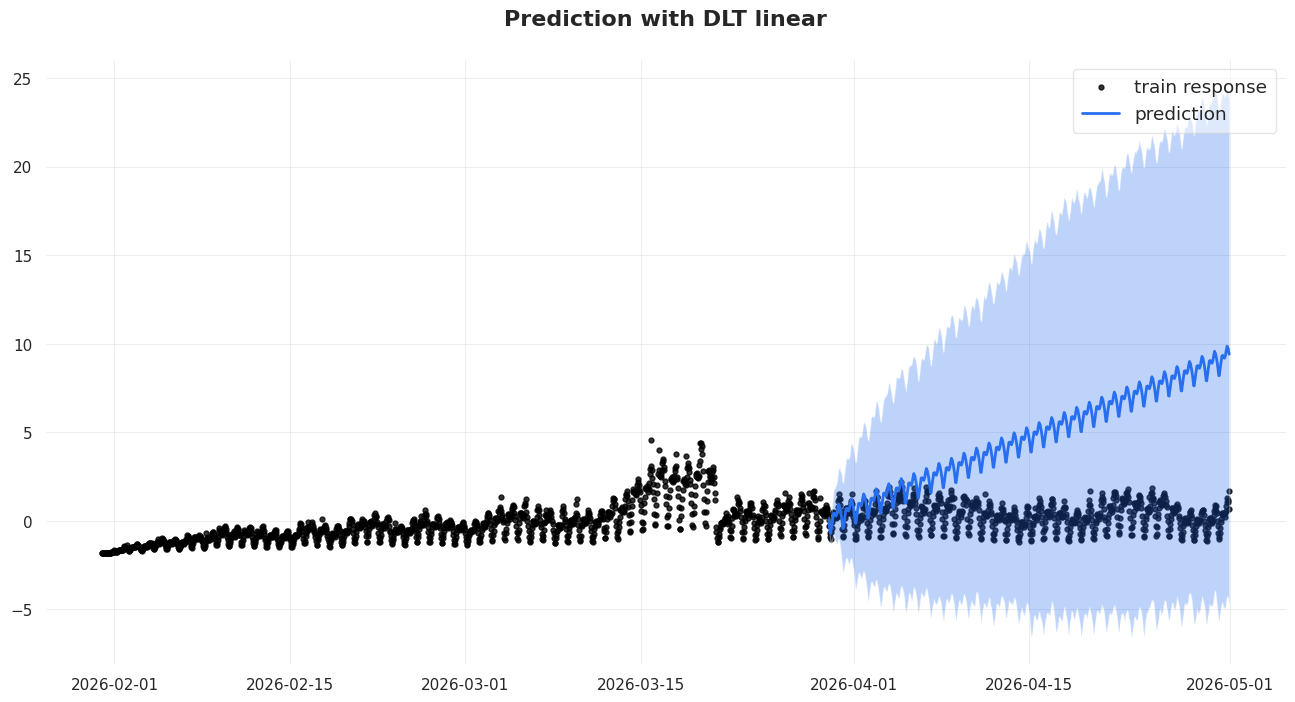

In [63]:
_ = plot_predicted_data(activity, predicted_df_1, "hour_time", 'activity_stand', title='Prediction with DLT linear')

На графике выше изображён прогноз метрики сдоверительными интервалами. Можно заметить, что метрика активности, по результатам прогнозирования данной моделью линейна и резко возрастает, колеблется вокруг определённого значения. Однако, можно заметить, что прогноз выглядит завышенным относительно основного тренда активности.

In [64]:
#с декомпозицией предсказания
predicted_df_1 = dlt_linear.predict(df=test_dat, decompose=True) #говорит, что нам нужна декомпозиция предсказания
predicted_df_1.head()

,hour_time,prediction_5,prediction,prediction_95,trend_5,trend,trend_95,seasonality_5,seasonality,seasonality_95,regression_5,regression,regression_95
0,2026-03-30 00:00:00,-0.112619,0.063829,0.255000,-0.042449,0.133999,0.325170,-0.070170,-0.070170,-0.070170,0.0,0.0,0.0
1,2026-03-30 01:00:00,-0.488203,-0.162981,0.154188,-0.188057,0.137165,0.454334,-0.300146,-0.300146,-0.300146,0.0,0.0,0.0
2,2026-03-30 02:00:00,-0.905895,-0.452561,-0.008706,-0.311241,0.142093,0.585948,-0.594654,-0.594654,-0.594654,0.0,0.0,0.0
3,2026-03-30 03:00:00,-1.276965,-0.689827,-0.093058,-0.438706,0.148432,0.745201,-0.838259,-0.838259,-0.838259,0.0,0.0,0.0
4,2026-03-30 04:00:00,-1.396613,-0.702510,-0.008280,-0.538204,0.155899,0.850129,-0.858409,-0.858409,-0.858409,0.0,0.0,0.0


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

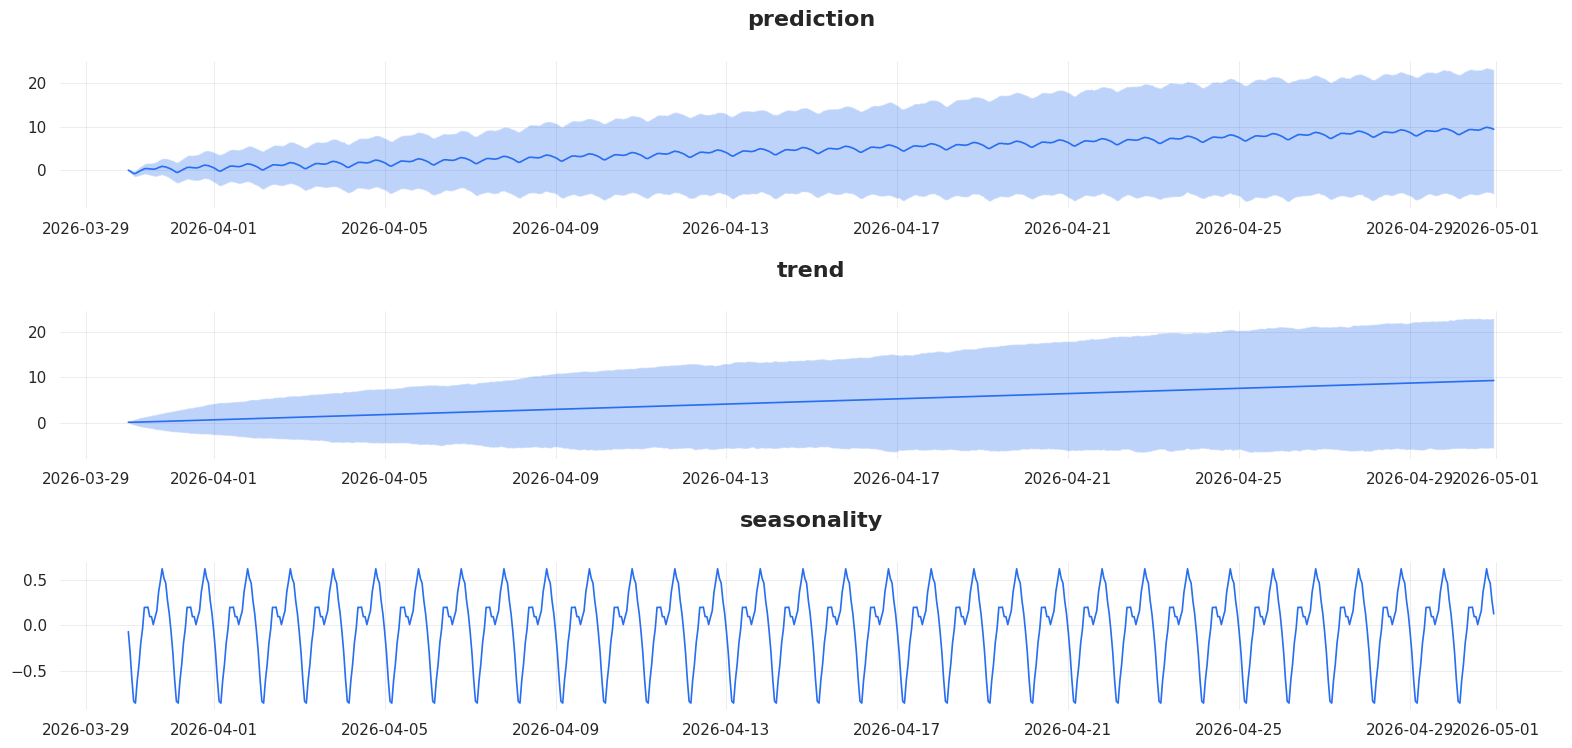

In [65]:
_ = plot_predicted_components(predicted_df_1, "hour_time", plot_components=['prediction', 'trend', 'seasonality'])

На данном графике видны компоненты: предсказание с расширяющимся доверительным интервалом, возрастающий тренд, и постоянная внутрисуточная сезонность метрики.

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

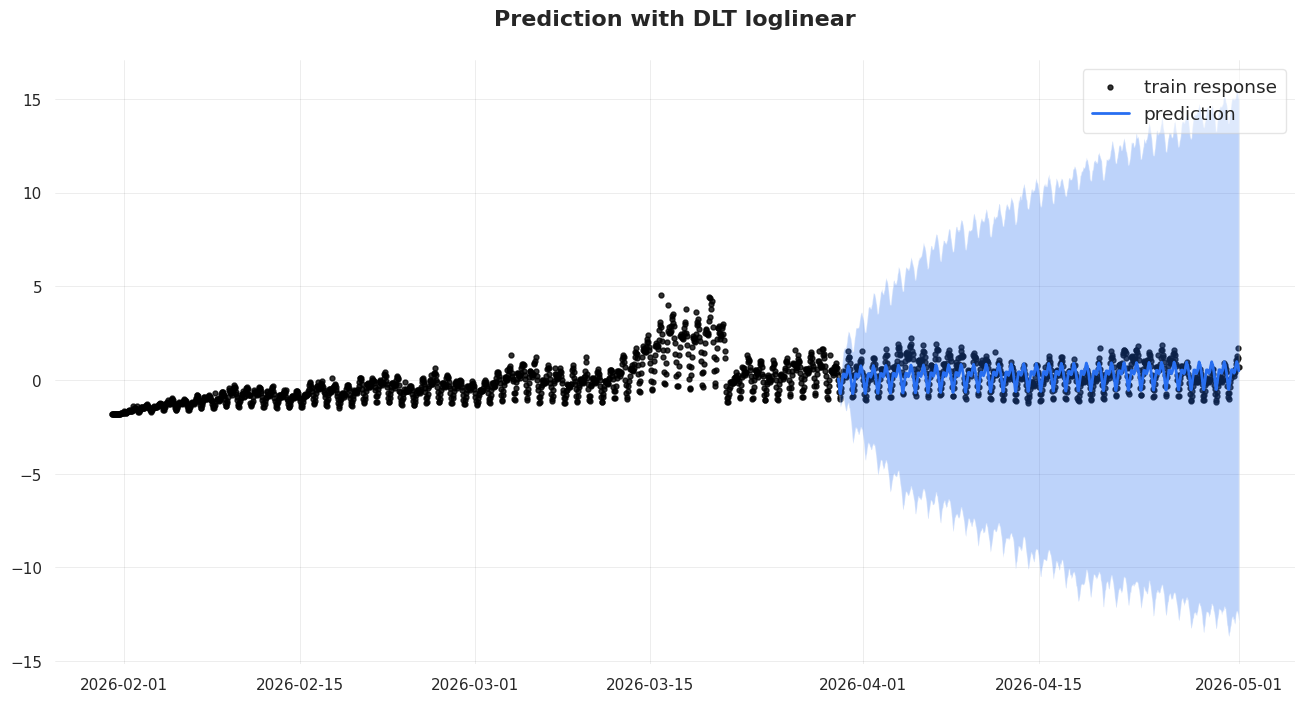

In [67]:
_ = plot_predicted_data(activity, predicted_df_2, "hour_time", 'activity_stand', title='Prediction with DLT loglinear')

Данный прогноз отличается от предыдущего. Прогноз метрики активности линеен, колеблется вокруг постоянного уровня, более удачно соответствует реальным данным.

#### Делаем прогноз с помощью dlt_mcmc

In [68]:
predicted_df_3 = dlt_mcmc.predict(df=test_dat)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

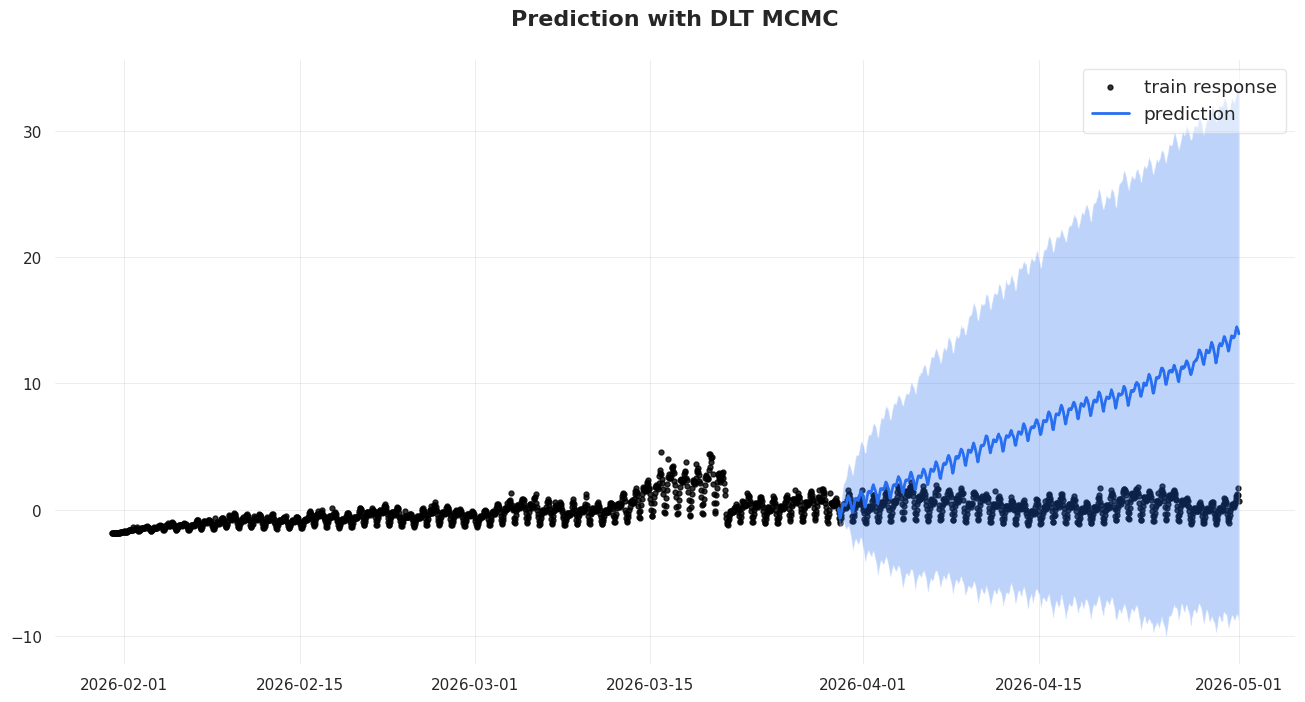

In [69]:
_ = plot_predicted_data(activity, predicted_df_3, "hour_time", 'activity_stand', title='Prediction with DLT MCMC')

На графике выше изображён прогноз метрики. Считается, что прогнозы, построенные моделью MCMC являются более точными и качественными, так как данная модель оценивает все доверительные интервалы для всех компонентов данных, оценивает тенденции и изменчивость данных. Можно заметить, что границы прогнозного интервала, в рамках которого прогнозируется поведение метрики такие же широкие, как и у предыдущих моделей, и общий тренд предсказываемой метрики возрастает.

In [70]:
# декомпозиция
predicted_df_3 = dlt_mcmc.predict(df=future_df, decompose=True)
predicted_df_3.head()

,hour_time,prediction_5,prediction,prediction_95,trend_5,trend,trend_95,seasonality_5,seasonality,seasonality_95,regression_5,regression,regression_95
0,2026-04-14 00:00:00,-0.112711,0.058605,0.246859,-0.034527,0.149004,0.338683,-0.149762,-0.089226,-0.026475,0.0,0.0,0.0
1,2026-04-14 01:00:00,-0.445865,-0.161794,0.149537,-0.141228,0.143105,0.462936,-0.367196,-0.308997,-0.247550,0.0,0.0,0.0
2,2026-04-14 02:00:00,-0.888612,-0.471458,-0.003212,-0.276287,0.143571,0.613549,-0.674142,-0.614209,-0.553496,0.0,0.0,0.0
3,2026-04-14 03:00:00,-1.232932,-0.687764,-0.079619,-0.407288,0.152435,0.758494,-0.899470,-0.841328,-0.777081,0.0,0.0,0.0
4,2026-04-14 04:00:00,-1.377587,-0.672709,0.065365,-0.536357,0.161156,0.899514,-0.884787,-0.830562,-0.765272,0.0,0.0,0.0


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

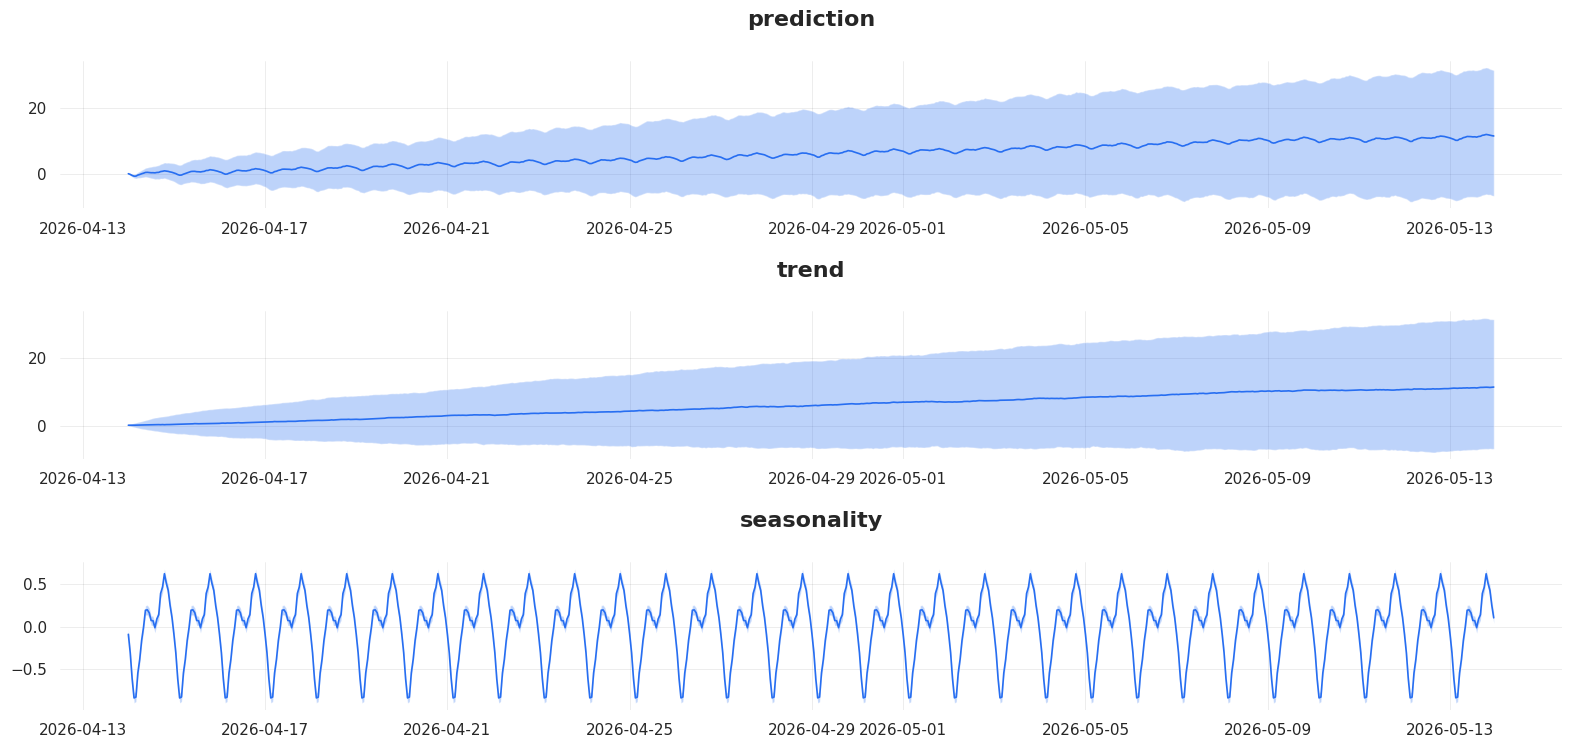

In [71]:
_ = plot_predicted_components(predicted_df_3, "hour_time", plot_components=['prediction', 'trend', 'seasonality'])

#### Построим прогнозы с помощью моделей dau_linear и dau_loglinear

In [42]:
(activity[['hour_time','activity_stand', 'DAU_stand', 'is_flashmob']]).drop("hour_time", axis=1).corr()

,activity_stand,DAU_stand,is_flashmob
activity_stand,1.000000,0.818953,0.519242
DAU_stand,0.818953,1.000000,0.121717
is_flashmob,0.519242,0.121717,1.000000


Взглянем на корреляцию. Ориентируясь на коэффиценты корреляции, активность хорошо коррелирует с DAU, значение близко к 1, и хуже коррелирует с бинарным регрессором, показывающим аномальные даты флешмоба.

In [72]:
predicted_df_4 = dau_linear.predict(df=test_dat)
predicted_df_5 = dau_loglinear.predict(df=test_dat)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

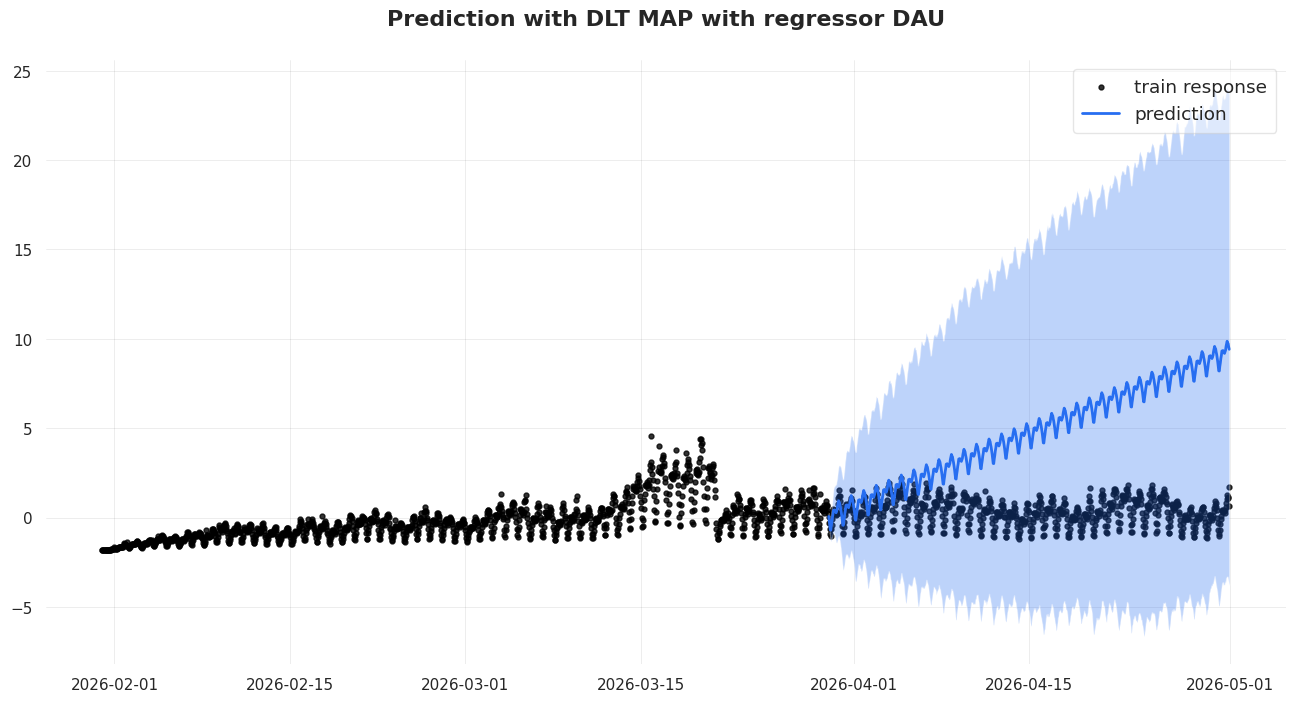

In [73]:
_ = plot_predicted_data(activity, predicted_df_4, "hour_time", 'activity_stand', title='Prediction with DLT MAP with regressor DAU')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

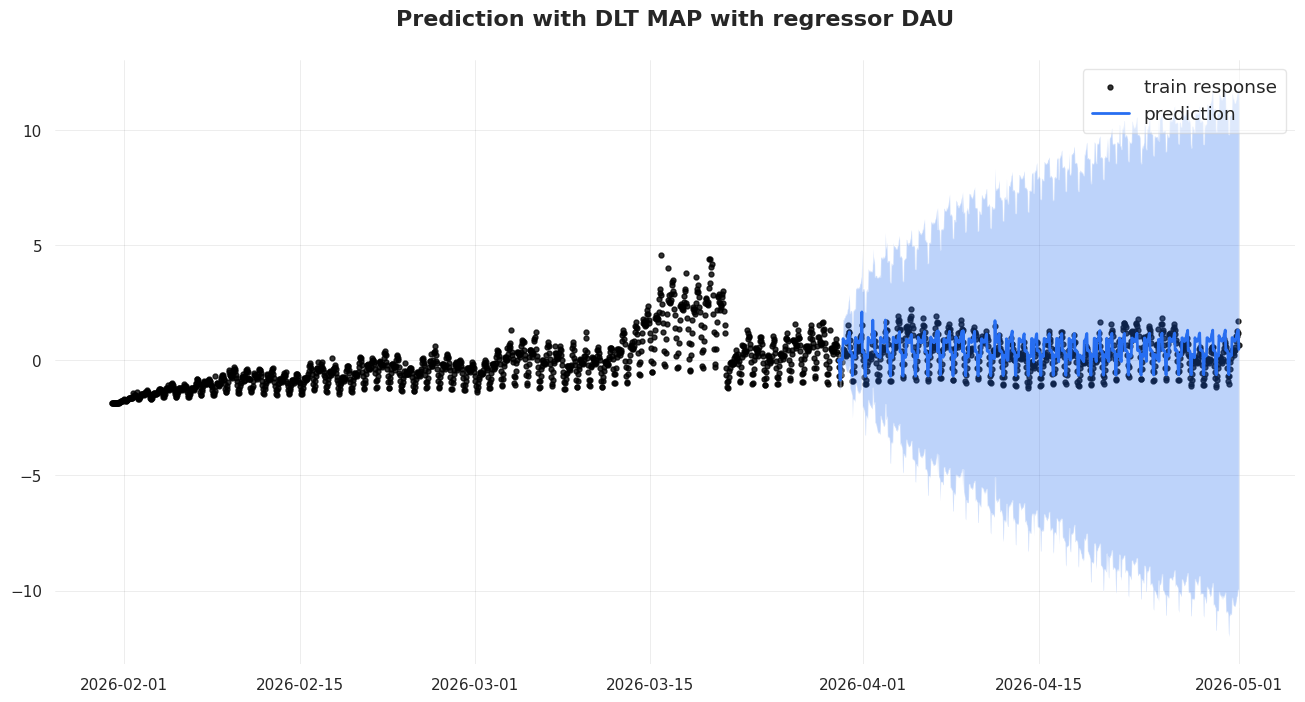

In [74]:
_ = plot_predicted_data(activity, predicted_df_5, "hour_time", 'activity_stand', title='Prediction with DLT MAP with regressor DAU')

В целом, для этих графиков предсказаний верны предыдущие замечания: прогнозы модели с линейным трендом завышаются, прогнозы модели с логлинейным трендом более горизонтальны, выходят на плато, и лучше описывают реальные данные. 

#### Построим прогнозы с помощью моделей anomaly_linear anomaly_loglinear, то есть сразу с двумя регрессорами : DAU и датами флешмоба

In [75]:
predicted_df_6 = anomaly_linear.predict(df=test_dat)
predicted_df_7 = anomaly_loglinear.predict(df=test_dat)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

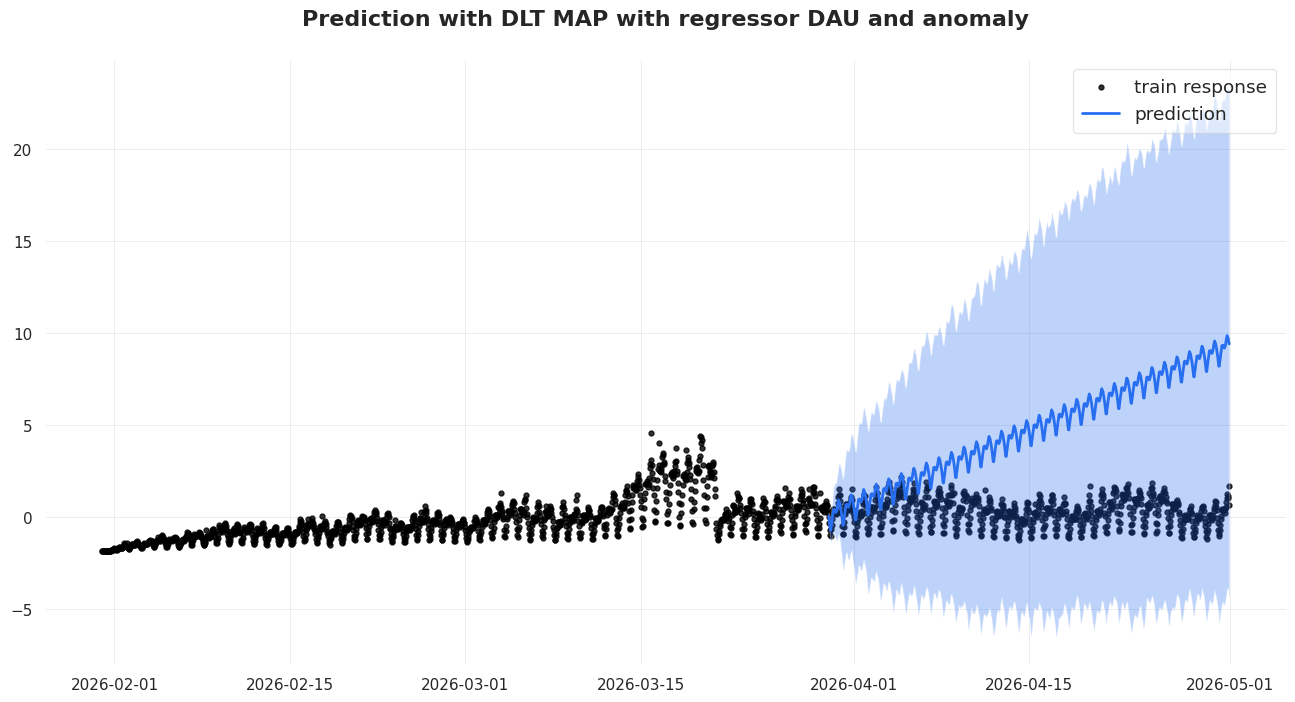

In [76]:
_ = plot_predicted_data(activity, predicted_df_6, "hour_time", 'activity_stand', title='Prediction with DLT MAP with regressor DAU and anomaly')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

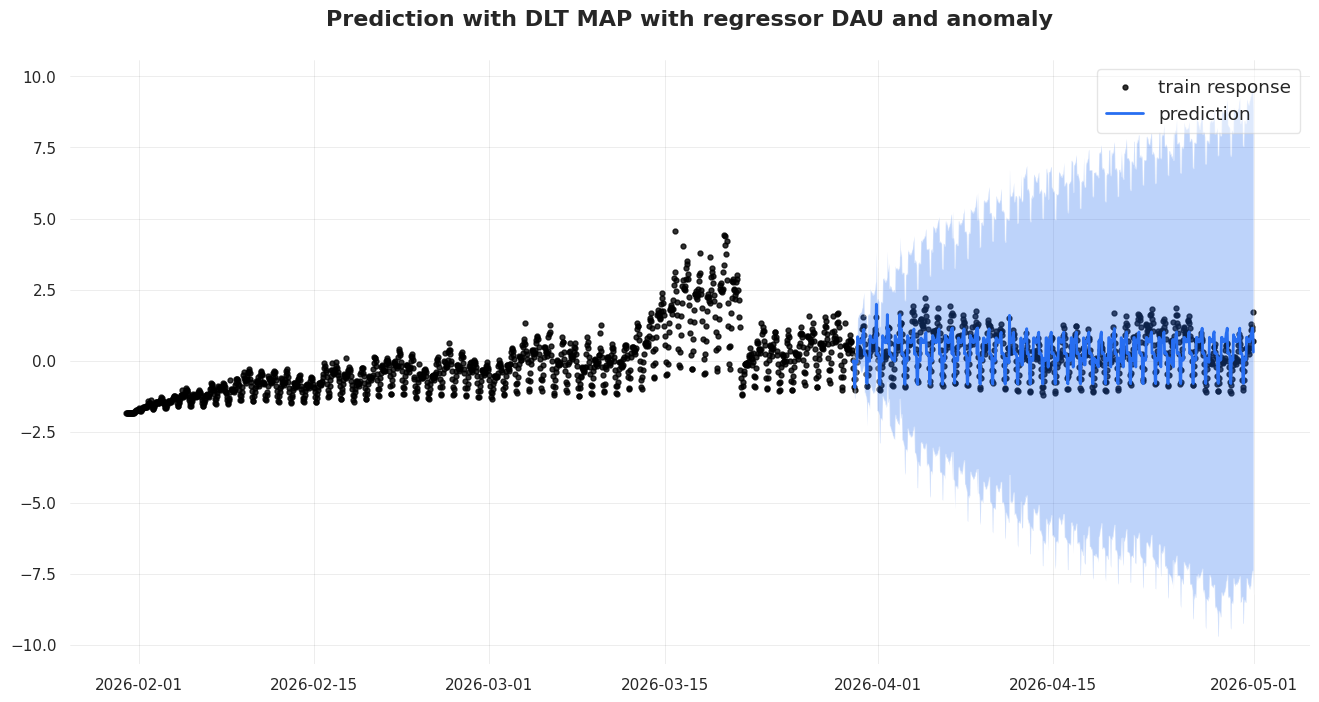

In [77]:
_ = plot_predicted_data(activity, predicted_df_7, "hour_time", 'activity_stand', title='Prediction with DLT MAP with regressor DAU and anomaly')

#### Оценим качество моделей

In [78]:
from orbit.diagnostics.backtest import BackTester #основной класс для бэктестинга 
from orbit.utils.params_tuning import grid_search_orbit #для подбора оптимальных параметров

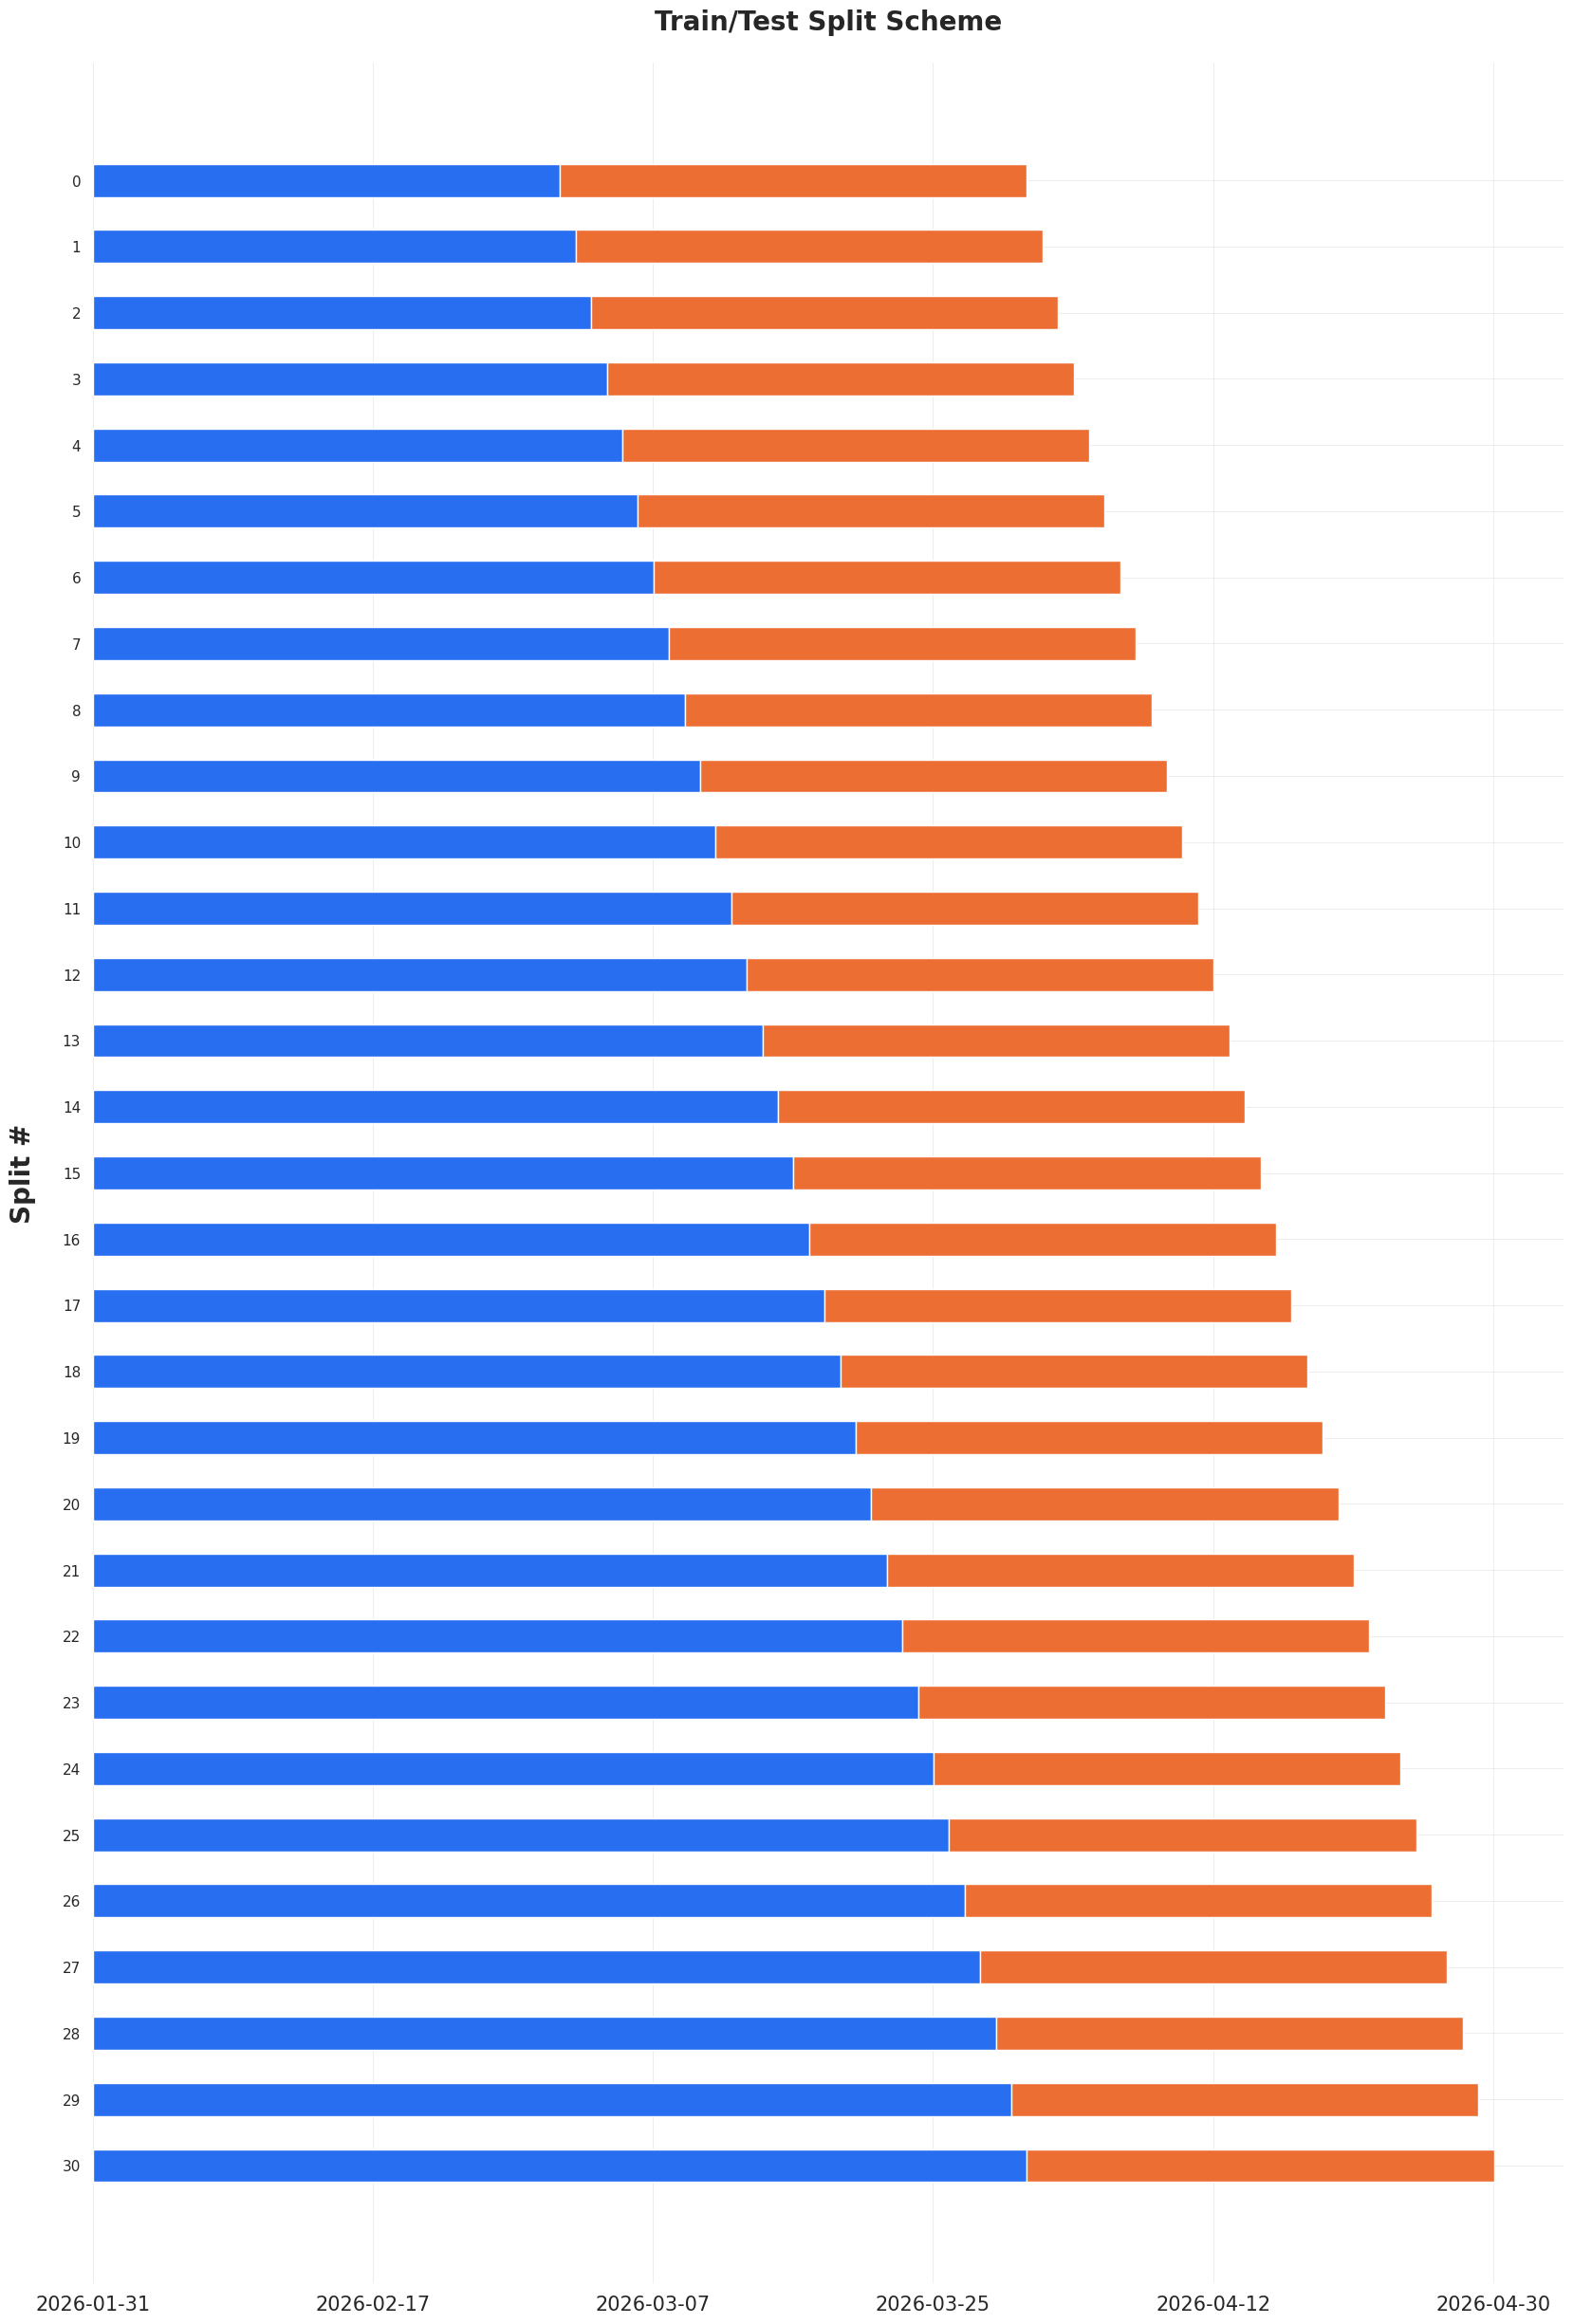

In [79]:
#expanding окно

bt_exp = BackTester(
    model=dlt_linear, #наша моделька
    df=activity, #датафрейм для обучения
    min_train_len=24*30, #самый маленький кусочек данных, с которого начинается обучение
    incremental_len=24, #на сколько происходит прирост тренировочных данных
    forecast_len=24*30, #горизонт пронозирования
    window_type="expanding" #тип окошка
)
bt_exp.plot_scheme()

Если брать горизонт прогнозирования- 30 дней, то нам, очевидно, не хватает данных. Нужно больше наблюдений. Поэтому можно взять горизнот прогнозирования размером в 1 неделю. Для этого у нас данных хватает.

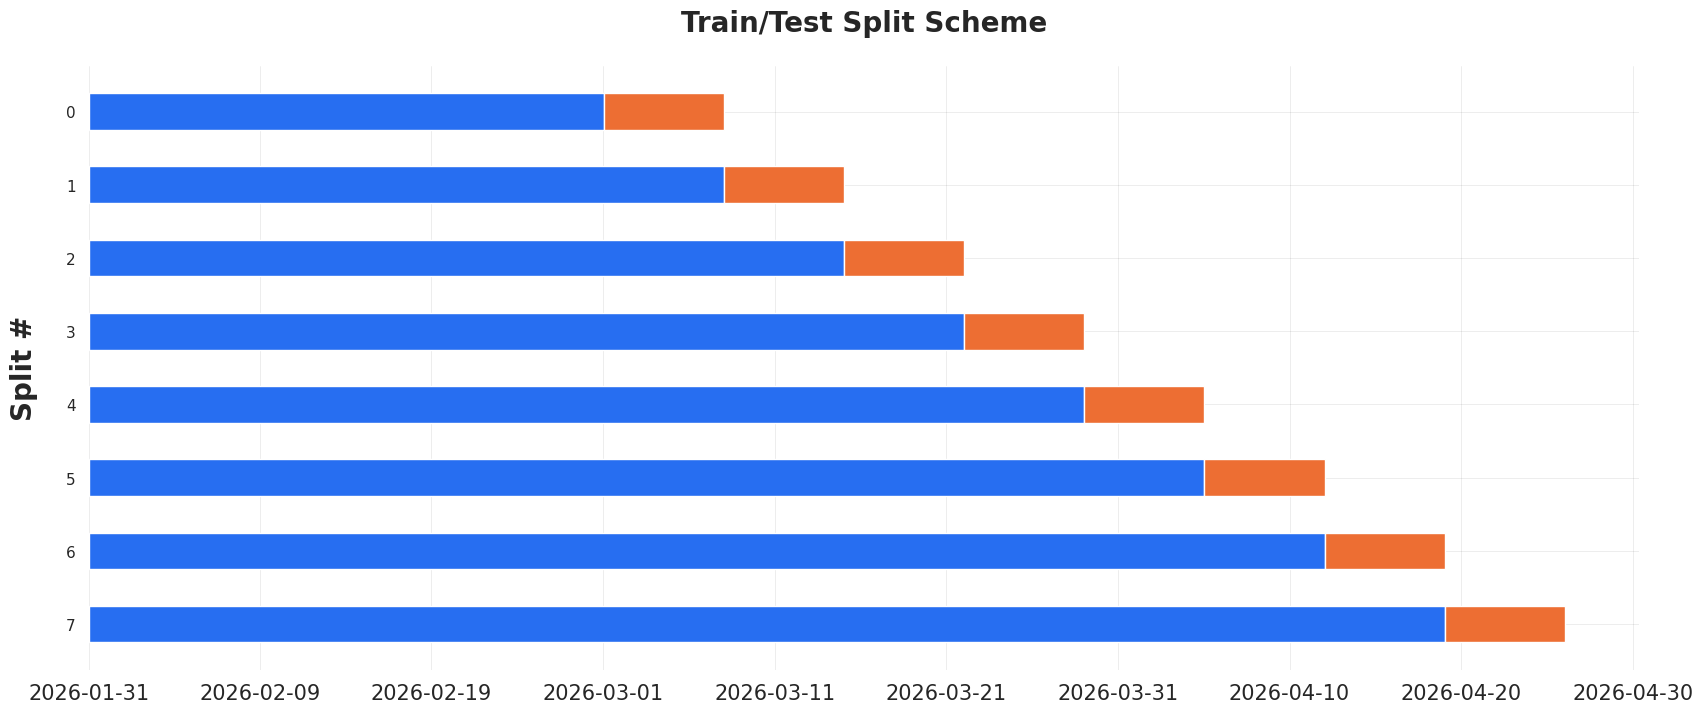

In [81]:
#expanding окно

bt_exp = BackTester(
    model=dlt_linear, #наша моделька
    df=activity, #датафрейм для обучения
    min_train_len=24*30, #самый маленький кусочек данных, с которого начинается обучение -месяц
    incremental_len=24*7, #на сколько происходит прирост тренировочных данных на неделю
    forecast_len=24*7, #горизонт прогнозирования
    window_type="expanding" #тип окошка
)
bt_exp.plot_scheme()

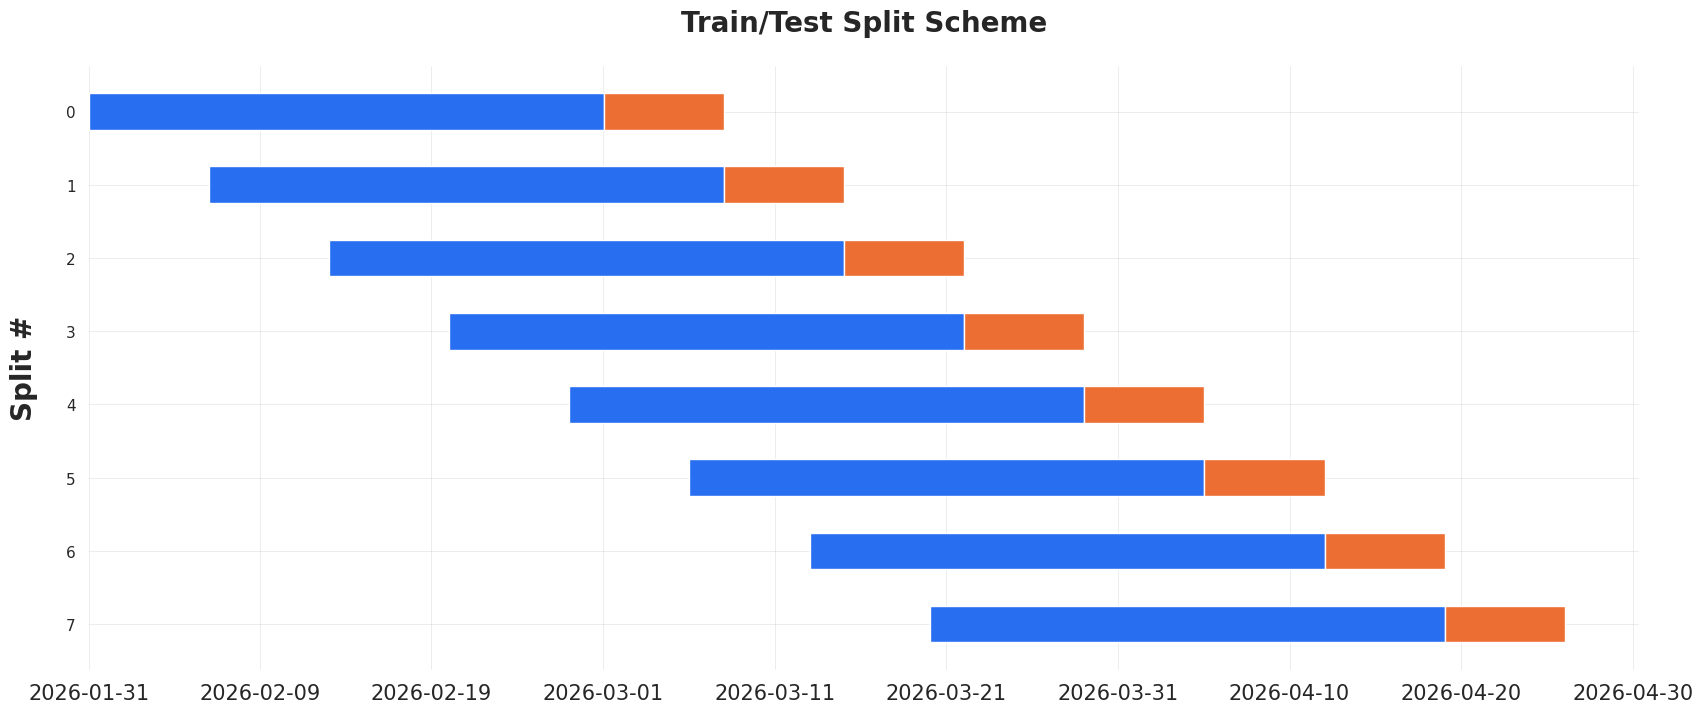

In [82]:
#rolling скользящее окно

bt_roll = BackTester(
    model=dlt_linear,
    df=activity,
    min_train_len=24*30,
    incremental_len=24*7,
    forecast_len=24*7,
    window_type="rolling",
)
bt_roll.plot_scheme()

In [83]:
#Оценим, как меняется точность предсказания модели в зависимости от размера тренировочных данных. Рассчитаем показатели ошибок 
#expanding window
test_list_exp = []

for model in models_list:
    backtester = BackTester(
    model=model,
    df=activity,
    min_train_len=24*30,
    incremental_len=24*7,
    forecast_len=24*7,
    window_type="expanding")
    backtester.fit_predict()
    test_list_exp.append(backtester)

2026-05-30 20:38:20 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

2026-05-30 20:55:23 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [84]:
exp_df = []

for number, tester in enumerate(test_list_exp): 
    inter_df = tester.score() # из списка бектестеров получим значение метрик и вставим колонку с номером модели
    inter_df.insert(0, "model_number", number + 1)
    
    exp_df.append(inter_df) #добавим получившийся датафрейм в список
    
exp_df = pd.concat(exp_df) #обьединим все датафреймы вертикально 
exp_df = exp_df.set_index("model_number")

for metric in exp_df.metric_name.unique(): #для каждой метрики ошибок модели
    
    winning_model = exp_df.loc[exp_df.metric_name == metric].metric_values.idxmin() #ищем модель, у которой значение метрики самое минимальное- значит, она ошиблась меньше всего.
    
    print(f"Самая лучшая модель по метрике {metric} - {winning_model}")

Самая лучшая модель по метрике smape - 5
Самая лучшая модель по метрике wmape - 5
Самая лучшая модель по метрике mape - 7
Самая лучшая модель по метрике mse - 5
Самая лучшая модель по метрике mae - 5
Самая лучшая модель по метрике rmsse - 5


Видим, что в большинстве случаев победила модель 5- dau_loglinear. DLT модель с логлинейным трендом и регрессором DAU

In [85]:
#также сделаем для скользящего

test_list_rolling = []

for model in models_list:
    
    backtester = BackTester(
    model=model,
    df=activity,
    min_train_len=24*30,
    incremental_len=24*7,
    forecast_len=24*7,
    window_type="rolling")
    
    backtester.fit_predict()
    
    test_list_rolling.append(backtester)

2026-05-30 21:05:02 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

2026-05-30 21:14:53 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [87]:
roll_df = []

for number, tester in enumerate(test_list_rolling):
    
    inter_df = tester.score()
    inter_df.insert(0, "model_number", number + 1)
    
    roll_df.append(inter_df)
    
roll_df = pd.concat(roll_df)
roll_df = roll_df.set_index("model_number")

In [88]:
for metric in roll_df.metric_name.unique():
    
    winning_model = roll_df.loc[roll_df.metric_name == metric].metric_values.idxmin()
    
    print(f"Самая лучшая модель по метрике {metric} - {winning_model}")

Самая лучшая модель по метрике smape - 7
Самая лучшая модель по метрике wmape - 7
Самая лучшая модель по метрике mape - 7
Самая лучшая модель по метрике mse - 7
Самая лучшая модель по метрике mae - 7
Самая лучшая модель по метрике rmsse - 7


А здесь с бектестингом со скользящим окном победила другая модель -7. anomaly_loglinear. DLT модель с логлинейным трендом и двумя регрессорами: DAU и бинарным регрессором is_flashmob.

постараемся подобрать опитмальные параметры для этих моделей, а затем сравнить их метрики бектестингом

In [93]:
#можно постараться подобрать оптимальные параметры для этих моделей
best_params, tuned_df = grid_search_orbit(param_grid={"damped_factor": np.arange(0.1, 1.0, 0.1)}, #наш параметр угасания тренда
                                        model=dau_loglinear,
                                        df=activity,
                                        min_train_len=24*30,
                                        incremental_len=24,
                                        forecast_len=24*30,
                                        metrics=None, #смотрим smape по умолчанию
                                        criteria="min", #говорим, что нам нужна минимизация
                                        verbose=True) #пусть печатает процесс выполнения

  0%|          | 0/9 [00:00<?, ?it/s]

2026-05-30 21:27:33 - orbit - INFO - tuning hyper-params {'damped_factor': 0.1}
2026-05-30 21:27:33 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-05-30 21:28:36 - orbit - INFO - tuning metric:0.96448
2026-05-30 21:28:36 - orbit - INFO - tuning hyper-params {'damped_factor': 0.2}
2026-05-30 21:28:36 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-05-30 21:29:44 - orbit - INFO - tuning metric:0.97186
2026-05-30 21:29:44 - orbit - INFO - tuning hyper-params {'damped_factor': 0.30000000000000004}
2026-05-30 21:29:44 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-05-30 21:30:53 - orbit - INFO - tuning metric:0.96793
2026-05-30 21:30:53 - orbit - INFO - tuning hyper-params {'damped_factor': 0.4}
2026-05-30 21:30:53 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-05-30 21:32:07 - orbit - INFO - tuning metric:1.006
2026-05-30 21:32:07 - orbit - INFO - tuning hyper-params {'damped_factor': 0.5}
2026-05-30 21:32:07 - orbit - 

In [94]:
best_params # Самая минимальная метрика smape = 0.96 для damped factor = 0.1. По умолчанию стоит значение 0.8. Изменим его на 0.1

[{'damped_factor': 0.1}]

In [95]:
#можно постараться подобрать оптимальные параметры для этих моделей
best_params, tuned_df = grid_search_orbit(param_grid={"damped_factor": np.arange(0.1, 1.0, 0.1)}, #наш параметр угасания тренда
                                        model=anomaly_loglinear,
                                        df=activity,
                                        min_train_len=24*30,
                                        incremental_len=24,
                                        forecast_len=24*30,
                                        metrics=None, #смотрим smape по умолчанию
                                        criteria="min", #говорим, что нам нужна минимизация
                                        verbose=True) #пусть печатает процесс выполнения

  0%|          | 0/9 [00:00<?, ?it/s]

2026-05-30 21:40:09 - orbit - INFO - tuning hyper-params {'damped_factor': 0.1}
2026-05-30 21:40:09 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-05-30 21:41:12 - orbit - INFO - tuning metric:0.99063
2026-05-30 21:41:12 - orbit - INFO - tuning hyper-params {'damped_factor': 0.2}
2026-05-30 21:41:12 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-05-30 21:42:21 - orbit - INFO - tuning metric:0.98253
2026-05-30 21:42:21 - orbit - INFO - tuning hyper-params {'damped_factor': 0.30000000000000004}
2026-05-30 21:42:21 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-05-30 21:43:30 - orbit - INFO - tuning metric:1.0127
2026-05-30 21:43:30 - orbit - INFO - tuning hyper-params {'damped_factor': 0.4}
2026-05-30 21:43:30 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
2026-05-30 21:44:42 - orbit - INFO - tuning metric:1.0075
2026-05-30 21:44:42 - orbit - INFO - tuning hyper-params {'damped_factor': 0.5}
2026-05-30 21:44:42 - orbit - 

In [96]:
best_params

[{'damped_factor': 0.5}]

In [98]:
#сравним качество с помощью бектестинга с expanding window старой модели dau_loglinear и изменённой модели dau_loglinear с damped_factor = 0.1
dau_loglinear_01= DLT(response_col="activity_stand", 
               date_col="hour_time", 
               seasonality=24,
               estimator="stan-map", 
               n_bootstrap_draws=1000,
               global_trend_option="loglinear",
               regressor_col=["DAU_stand"], regressor_sign=["+"],
               damped_factor=0.1)

dau_loglinear_list=[dau_loglinear, dau_loglinear_01]

dau_list_exp = []

for model in dau_loglinear_list:
    backtester = BackTester(
    model=model,
    df=activity,
    min_train_len=24*30,
    incremental_len=24*7,
    forecast_len=24*7,
    window_type="expanding")
    backtester.fit_predict()
    dau_list_exp.append(backtester)
    
dau_exp_df = []
for number, tester in enumerate(dau_list_exp): 
    dau_inter_df = tester.score() # из списка бектестеров получим значение метрик и вставим колонку с номером модели
    dau_inter_df.insert(0, "model_number", number + 1)
    
    dau_exp_df.append(dau_inter_df) #добавим получившийся датафрейм в список
    
dau_exp_df = pd.concat(dau_exp_df) #обьединим все датафреймы вертикально 
dau_exp_df = dau_exp_df.set_index("model_number")

for metric in dau_exp_df.metric_name.unique(): #для каждой метрики ошибок модели
    
    winning_model = dau_exp_df.loc[dau_exp_df.metric_name == metric].metric_values.idxmin() #ищем модель, у которой значение метрики самое минимальное- значит, она ошиблась меньше всего.
    
    print(f"Самая лучшая модель по метрике {metric} - {winning_model}")

2026-05-30 21:53:21 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.


Самая лучшая модель по метрике smape - 2
Самая лучшая модель по метрике wmape - 2
Самая лучшая модель по метрике mape - 2
Самая лучшая модель по метрике mse - 2
Самая лучшая модель по метрике mae - 2
Самая лучшая модель по метрике rmsse - 2


Видим- теперь по всем метрикам ошибок лучшей оказалась модель с изменённым damped_factor dau_loglinear_01.

In [99]:
dau_list_roll = []

for model in dau_loglinear_list:
    backtester = BackTester(
    model=model,
    df=activity,
    min_train_len=24*30,
    incremental_len=24*7,
    forecast_len=24*7,
    window_type="rolling")
    backtester.fit_predict()
    dau_list_roll.append(backtester)
    
dau_roll_df = []
for number, tester in enumerate(dau_list_roll): 
    dau_inter_df = tester.score() # из списка бектестеров получим значение метрик и вставим колонку с номером модели
    dau_inter_df.insert(0, "model_number", number + 1)
    
    dau_roll_df.append(dau_inter_df) #добавим получившийся датафрейм в список
    
dau_roll_df = pd.concat(dau_roll_df) #обьединим все датафреймы вертикально 
dau_roll_df = dau_roll_df.set_index("model_number")

for metric in dau_roll_df.metric_name.unique(): #для каждой метрики ошибок модели
    
    winning_model = dau_roll_df.loc[dau_roll_df.metric_name == metric].metric_values.idxmin() #ищем модель, у которой значение метрики самое минимальное- значит, она ошиблась меньше всего.
    
    print(f"Самая лучшая модель по метрике {metric} - {winning_model}")

Самая лучшая модель по метрике smape - 2
Самая лучшая модель по метрике wmape - 2
Самая лучшая модель по метрике mape - 2
Самая лучшая модель по метрике mse - 1
Самая лучшая модель по метрике mae - 2
Самая лучшая модель по метрике rmsse - 1


Если теперь сравнить эти модели бектестингом с rolling window- то в большинстве случаев лучшей оказывается также изменённая модель dau_loglinear_01.

Можно сравнить BIC этих моделей.

In [101]:
dau_loglinear_01.fit(train_dat)
predicted_df_8 = dau_loglinear_01.predict(df=test_dat)

In [102]:
print(f'для dau_loglinear_01 BIC= {dau_loglinear_01.get_bic()}')
print(f'для dau_loglinear BIC= {dau_loglinear.get_bic()}')

для dau_loglinear_01 BIC= -2779.0490989583004
для dau_loglinear BIC= -2860.1794469783003


BIC меньше у dau_loglinear

In [106]:
from orbit.diagnostics.metrics import rmsse #сравним через метрику rmsse

In [107]:
print(f"для dau_loglinear_01: {rmsse(test_dat.activity_stand.values, predicted_df_8.prediction.values, train_dat.activity_stand.values)}")
print(f"для dau_loglinear: {rmsse(test_dat.activity_stand.values, predicted_df_5.prediction.values, train_dat.activity_stand.values)}")

для dau_loglinear_01: 1.8926769402790837
для dau_loglinear: 1.7729375993223107


Здесь делаем вывод в пользу dau_loglinear_01

**Мы также подбирали damped_factor=0.5 для anomaly_loglinear. Проделаем тоже самое, сравним модели anomaly_loglinear и anomaly_loglinear_05**

In [108]:
#сравним качество с помощью бектестинга с expanding window старой модели anomaly_loglinear и изменённой модели anomaly_loglinear с damped_factor = 0.5
anomaly_loglinear_05 = DLT(response_col="activity_stand", 
               date_col="hour_time", 
               seasonality=24,
               estimator="stan-map",
               n_bootstrap_draws=1000,
               global_trend_option="loglinear",
               regressor_col=["DAU_stand", "is_flashmob"], regressor_sign=["+", "+"],
               damped_factor=0.5)
anom_loglinear_list=[anomaly_loglinear, anomaly_loglinear_05]

anom_list_exp = []

for model in anom_loglinear_list:
    backtester = BackTester(
    model=model,
    df=activity,
    min_train_len=24*30,
    incremental_len=24*7,
    forecast_len=24*7,
    window_type="expanding")
    backtester.fit_predict()
    anom_list_exp.append(backtester)
    
anom_exp_df = []
for number, tester in enumerate(anom_list_exp): 
    anom_inter_df = tester.score() # из списка бектестеров получим значение метрик и вставим колонку с номером модели
    anom_inter_df.insert(0, "model_number", number + 1)
    
    anom_exp_df.append(anom_inter_df) #добавим получившийся датафрейм в список
    
anom_exp_df = pd.concat(anom_exp_df) #обьединим все датафреймы вертикально 
anom_exp_df = anom_exp_df.set_index("model_number")

for metric in anom_exp_df.metric_name.unique(): #для каждой метрики ошибок модели
    
    winning_model = anom_exp_df.loc[anom_exp_df.metric_name == metric].metric_values.idxmin() #ищем модель, у которой значение метрики самое минимальное- значит, она ошиблась меньше всего.
    
    print(f"Самая лучшая модель по метрике {metric} - {winning_model}")

    
anom_list_roll = []

for model in anom_loglinear_list:
    backtester = BackTester(
    model=model,
    df=activity,
    min_train_len=24*30,
    incremental_len=24*7,
    forecast_len=24*7,
    window_type="rolling")
    backtester.fit_predict()
    anom_list_roll.append(backtester)
    
anom_roll_df = []
for number, tester in enumerate(anom_list_roll): 
    anom_inter_df = tester.score() # из списка бектестеров получим значение метрик и вставим колонку с номером модели
    anom_inter_df.insert(0, "model_number", number + 1)
    
    anom_roll_df.append(anom_inter_df) #добавим получившийся датафрейм в список
    
anom_roll_df = pd.concat(anom_roll_df) #обьединим все датафреймы вертикально 
anom_roll_df = anom_roll_df.set_index("model_number")

for metric in anom_roll_df.metric_name.unique(): #для каждой метрики ошибок модели
    
    winning_model = anom_roll_df.loc[anom_roll_df.metric_name == metric].metric_values.idxmin() #ищем модель, у которой значение метрики самое минимальное- значит, она ошиблась меньше всего.
    
    print(f"Самая лучшая модель по метрике {metric} - {winning_model}")

2026-05-30 22:18:29 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.


Самая лучшая модель по метрике smape - 1
Самая лучшая модель по метрике wmape - 1
Самая лучшая модель по метрике mape - 2
Самая лучшая модель по метрике mse - 1
Самая лучшая модель по метрике mae - 1
Самая лучшая модель по метрике rmsse - 1
Самая лучшая модель по метрике smape - 2
Самая лучшая модель по метрике wmape - 2
Самая лучшая модель по метрике mape - 2
Самая лучшая модель по метрике mse - 1
Самая лучшая модель по метрике mae - 2
Самая лучшая модель по метрике rmsse - 1


По результатам бектестинга с expanding window лучшей была модель anomaly_loglinear, а по бектестингу с rolling window- anomaly_loglinear_05

In [109]:
anomaly_loglinear_05.fit(train_dat)
predicted_df_9 = anomaly_loglinear_05.predict(df=test_dat)

In [110]:
print(f'для anomaly_loglinear_05 BIC= {anomaly_loglinear_05.get_bic()}')
print(f'для anomaly_loglinear BIC= {anomaly_loglinear.get_bic()}')

для anomaly_loglinear_05 BIC= -2900.7701734183006
для anomaly_loglinear BIC= -2817.8137800383006


BIC меньше у anomaly_loglinear_05

In [111]:
print(f"для anomaly_loglinear_05: {rmsse(test_dat.activity_stand.values, predicted_df_9.prediction.values, train_dat.activity_stand.values)}")
print(f"для anomaly_loglinear: {rmsse(test_dat.activity_stand.values, predicted_df_7.prediction.values, train_dat.activity_stand.values)}")

для anomaly_loglinear_05: 1.7735506455645593
для anomaly_loglinear: 1.6685344449174049


А метрика ошибок rmsse - у anomaly_loglinear

**Можно снова сравнить друг с другом эти новые модели, и выбрать лучшую**

In [112]:
#сравним качество с помощью бектестинга с expanding window и rolling window этих двух моделей
models_loglinear_list=[anomaly_loglinear_05, dau_loglinear_01]

models_list_exp = []

for model in models_loglinear_list:
    backtester = BackTester(
    model=model,
    df=activity,
    min_train_len=24*30,
    incremental_len=24*7,
    forecast_len=24*7,
    window_type="expanding")
    backtester.fit_predict()
    models_list_exp.append(backtester)
    
models_exp_df = []
for number, tester in enumerate(models_list_exp): 
    models_inter_df = tester.score() # из списка бектестеров получим значение метрик и вставим колонку с номером модели
    models_inter_df.insert(0, "model_number", number + 1)
    
    models_exp_df.append(models_inter_df) #добавим получившийся датафрейм в список
    
models_exp_df = pd.concat(models_exp_df) #обьединим все датафреймы вертикально 
models_exp_df = models_exp_df.set_index("model_number")

for metric in models_exp_df.metric_name.unique(): #для каждой метрики ошибок модели
    
    winning_model = models_exp_df.loc[models_exp_df.metric_name == metric].metric_values.idxmin() #ищем модель, у которой значение метрики самое минимальное- значит, она ошиблась меньше всего.
    
    print(f"Самая лучшая модель по метрике {metric} - {winning_model}")

    
models_list_roll = []

for model in models_loglinear_list:
    backtester = BackTester(
    model=model,
    df=activity,
    min_train_len=24*30,
    incremental_len=24*7,
    forecast_len=24*7,
    window_type="rolling")
    backtester.fit_predict()
    models_list_roll.append(backtester)
    
models_roll_df = []
for number, tester in enumerate(models_list_roll): 
    models_inter_df = tester.score() # из списка бектестеров получим значение метрик и вставим колонку с номером модели
    models_inter_df.insert(0, "model_number", number + 1)
    
    models_roll_df.append(models_inter_df) #добавим получившийся датафрейм в список
    
models_roll_df = pd.concat(models_roll_df) #обьединим все датафреймы вертикально 
models_roll_df = models_roll_df.set_index("model_number")

for metric in models_roll_df.metric_name.unique(): #для каждой метрики ошибок модели
    
    winning_model = models_roll_df.loc[models_roll_df.metric_name == metric].metric_values.idxmin() #ищем модель, у которой значение метрики самое минимальное- значит, она ошиблась меньше всего.
    
    print(f"Самая лучшая модель по метрике {metric} - {winning_model}")

Самая лучшая модель по метрике smape - 1
Самая лучшая модель по метрике wmape - 1
Самая лучшая модель по метрике mape - 1
Самая лучшая модель по метрике mse - 1
Самая лучшая модель по метрике mae - 1
Самая лучшая модель по метрике rmsse - 1
Самая лучшая модель по метрике smape - 1
Самая лучшая модель по метрике wmape - 1
Самая лучшая модель по метрике mape - 2
Самая лучшая модель по метрике mse - 1
Самая лучшая модель по метрике mae - 1
Самая лучшая модель по метрике rmsse - 1


Как мы видим, практически единогласно оба варианта бектестинга показали, что лучшей оказалась anomaly_loglinear_05

In [113]:
print(f'для anomaly_loglinear_05 BIC= {anomaly_loglinear_05.get_bic()}')
print(f'для dau_loglinear_01 BIC= {dau_loglinear_01.get_bic()}')

для anomaly_loglinear_05 BIC= -2900.7701734183006
для dau_loglinear_01 BIC= -2779.0490989583004


Тоже самое и по BIC

In [114]:
print(f"для anomaly_loglinear_05: {rmsse(test_dat.activity_stand.values, predicted_df_9.prediction.values, train_dat.activity_stand.values)}")
print(f"для dau_loglinear_01: {rmsse(test_dat.activity_stand.values, predicted_df_8.prediction.values, train_dat.activity_stand.values)}")

для anomaly_loglinear_05: 1.7735506455645593
для dau_loglinear_01: 1.8926769402790837


И по метрике rmsse

А также посмотрим на графики предсказаний этих моделей!

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

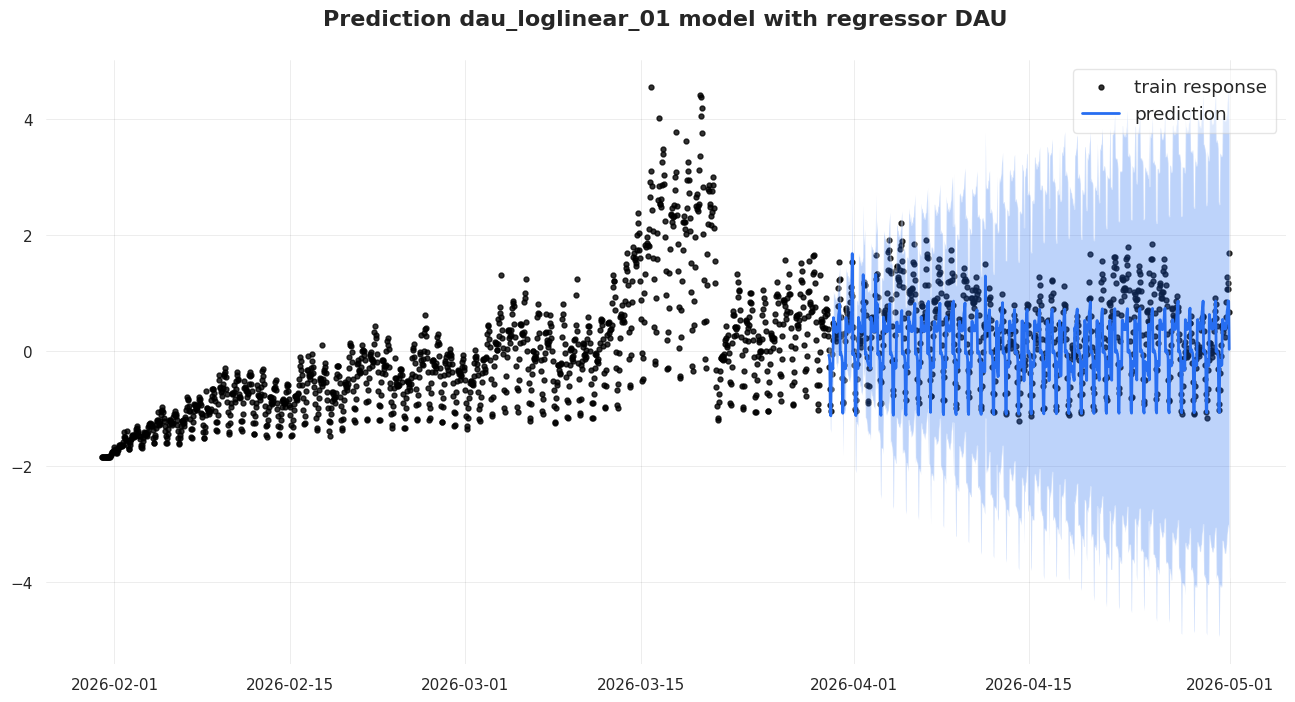

In [115]:
_ = plot_predicted_data(activity, predicted_df_8, "hour_time", 'activity_stand', title='Prediction dau_loglinear_01 model with regressor DAU')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

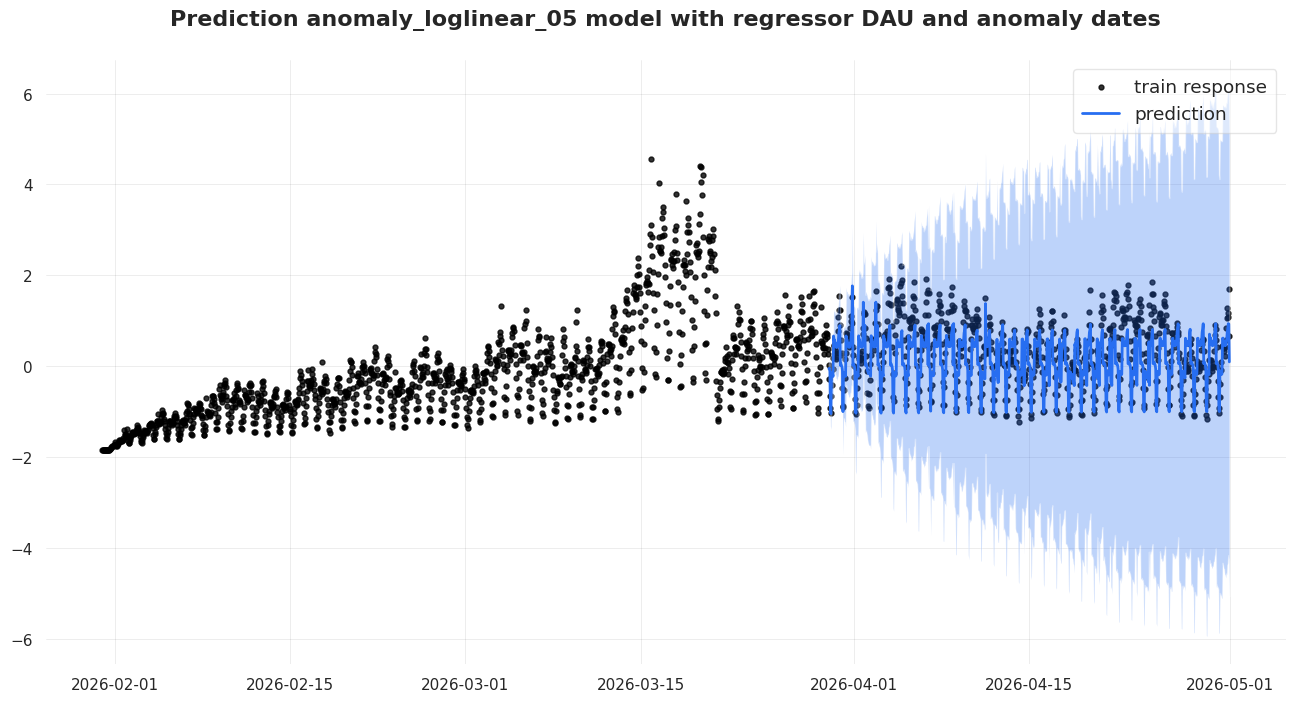

In [116]:
_ = plot_predicted_data(activity, predicted_df_9, "hour_time", 'activity_stand', title='Prediction anomaly_loglinear_05 model with regressor DAU and anomaly dates')

#### Проверим также и MCMC

array([[<Axes: title={'center': 'obs_sigma'}>,
        <Axes: title={'center': 'obs_sigma'}>]], dtype=object)

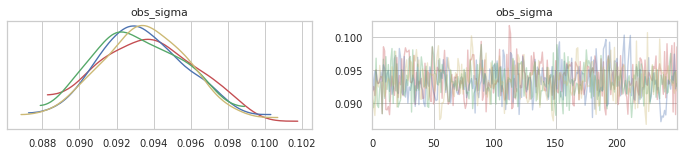

In [117]:
params = dlt_mcmc.get_posterior_samples(permute=False) #достаём информацию о параметрах
az.plot_trace(params, chain_prop={"color": ['r', 'b', 'g', 'y']}, var_names = "obs_sigma")

MCMC с данными найстройками также справилась хорошо. Цепи сошлись практически к одному значению, ни одна цепь заметно не выделяется. Это видно и на левом графике, и на правом. 

#### Вывод: 

По метрикам ошибок лучшей оказалась модель с двумя регрессорами и логлинейным трендом, с damped_factor=0.5

#### Регуляризация

Регуляризация- метод, чтобы решить проблемы с переобучением модели, он применяет систему штрафов к коэффициентам модели, особенно, если регрессор выбран не совсем оптимальным. К модели добавляется параметр regressor_penalty. Возьмём модель anomaly_loglinear_05.

In [120]:
#применим regressor_penalty = auto_ridge
anomaly_loglinear_05_auto = DLT(response_col="activity_stand", 
               date_col="hour_time", 
               seasonality=24,
               estimator="stan-map",
               n_bootstrap_draws=1000,
               global_trend_option="loglinear",
               regressor_col=["DAU_stand", "is_flashmob"], regressor_sign=["+", "+"],
               damped_factor=0.5,
               regression_penalty="auto_ridge")


anomaly_loglinear_05_auto.fit(train_dat)

2026-05-30 22:57:35 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.


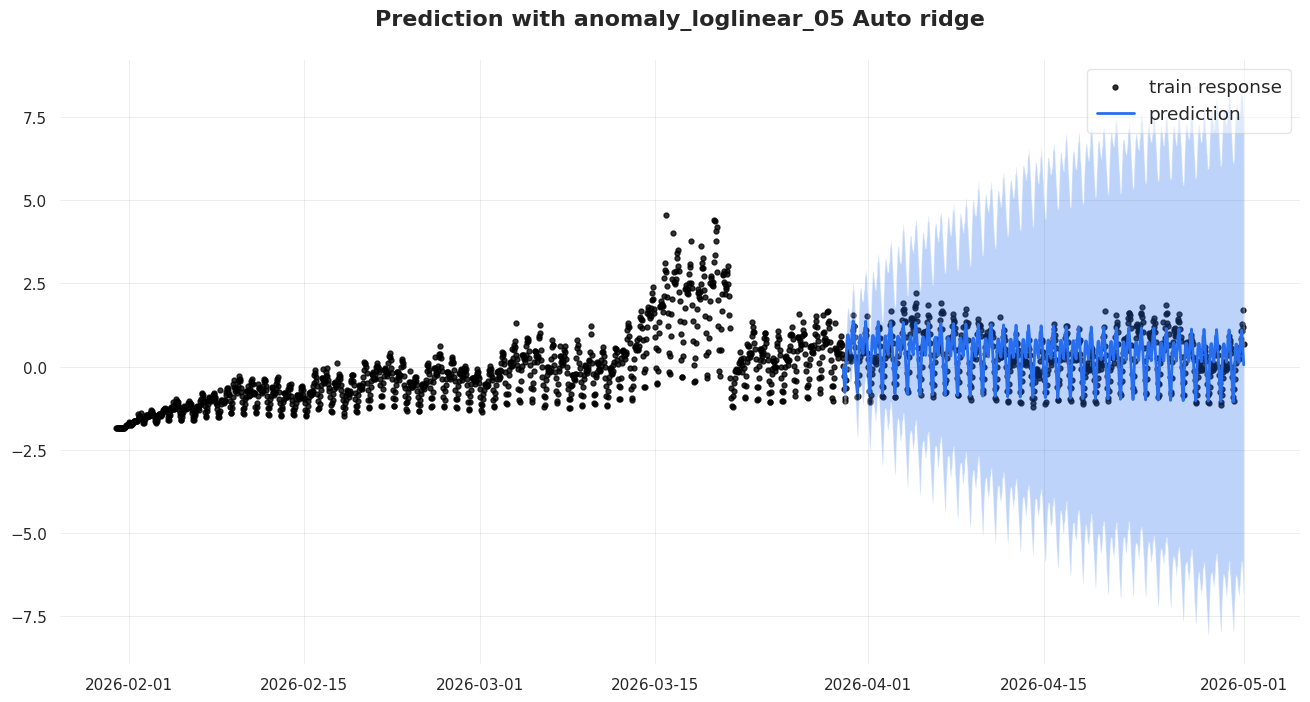

In [126]:
predicted_df_auto = anomaly_loglinear_05_auto.predict(df=test_dat)

_ = plot_predicted_data(activity, predicted_df_auto, "hour_time", 'activity_stand', title='Prediction with anomaly_loglinear_05 Auto ridge') 

In [125]:
#применим regression_penalty="lasso"
anomaly_loglinear_05_lasso = DLT(response_col="activity_stand", 
               date_col="hour_time", 
               seasonality=24,
               estimator="stan-map",
               n_bootstrap_draws=1000,
               global_trend_option="loglinear",
               regressor_col=["DAU_stand", "is_flashmob"], regressor_sign=["+", "+"],
               damped_factor=0.5,
               regression_penalty="lasso")
anomaly_loglinear_05_lasso.fit(train_dat)

2026-05-30 23:00:37 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.
INFO:orbit:Optimizing (PyStan) with algorithm: LBFGS.


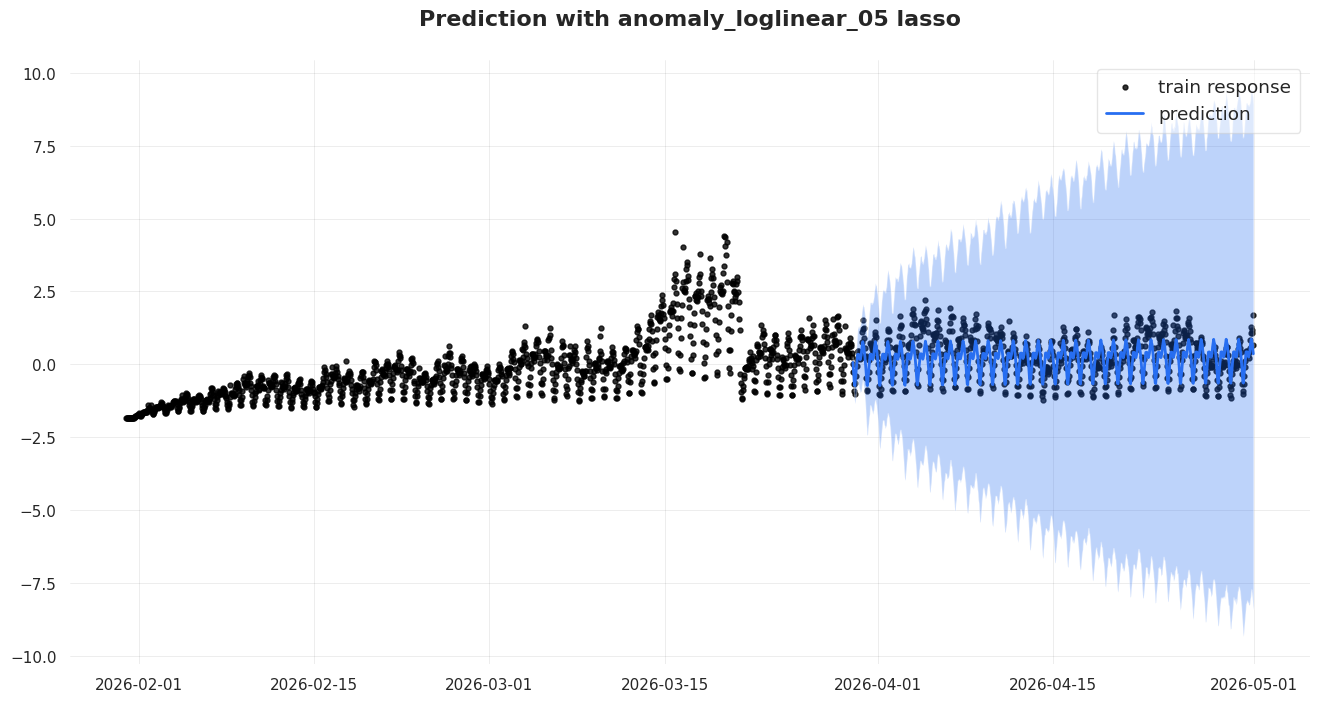

In [127]:
predicted_df_lasso = anomaly_loglinear_05_lasso.predict(df=test_dat)
_ = plot_predicted_data(activity, predicted_df_lasso, "hour_time", 'activity_stand', title='Prediction with anomaly_loglinear_05 lasso')

И снова посмотрим на информационные критерии: BIC

In [128]:
print(f"dau_loglinear: {dau_loglinear.get_bic()}")
print(f"dau_loglinear с damped_factor=0.1: {dau_loglinear_01.get_bic()}")
print(f"anomaly_loglinear: {anomaly_loglinear.get_bic()}")
print(f"anomaly_loglinear с damped_factor=0.5: {anomaly_loglinear_05.get_bic()}")
print(f"anomaly_loglinear c auto-ridge: {anomaly_loglinear_05_auto.get_bic()}")
print(f"anomaly_loglinear c lasso: {anomaly_loglinear_05_lasso.get_bic()}")

dau_loglinear: -2860.1794469783003
dau_loglinear с damped_factor=0.1: -2779.0490989583004
anomaly_loglinear: -2817.8137800383006
anomaly_loglinear с damped_factor=0.5: -2900.7701734183006
anomaly_loglinear c auto-ridge: -1042.2179144783004
anomaly_loglinear c lasso: -1515.1204958763003


Видим, что регуляризация не улучшила показатели нашей выбранной модели anomaly_loglinear_05, поэтому применять мы её не будем

In [129]:
print(f"dau_loglinear: {rmsse(test_dat.activity_stand.values, predicted_df_5.prediction.values, train_dat.activity_stand.values)}")
print(f"dau_loglinear с damped_factor=0.1: {rmsse(test_dat.activity_stand.values, predicted_df_8.prediction.values, train_dat.activity_stand.values)}")
print(f"anomaly_loglinear: {rmsse(test_dat.activity_stand.values, predicted_df_7.prediction.values, train_dat.activity_stand.values)}")
print(f"anomaly_loglinear с damped_factor=0.5: {rmsse(test_dat.activity_stand.values, predicted_df_9.prediction.values, train_dat.activity_stand.values)}")
print(f"anomaly_loglinear c auto-ridge: {rmsse(test_dat.activity_stand.values, predicted_df_auto.prediction.values, train_dat.activity_stand.values)}")
print(f"anomaly_loglinear c lasso: {rmsse(test_dat.activity_stand.values, predicted_df_lasso.prediction.values, train_dat.activity_stand.values)}")

dau_loglinear: 1.7729375993223107
dau_loglinear с damped_factor=0.1: 1.8926769402790837
anomaly_loglinear: 1.6685344449174049
anomaly_loglinear с damped_factor=0.5: 1.7735506455645593
anomaly_loglinear c auto-ridge: 1.516486903496177
anomaly_loglinear c lasso: 1.473015131477016


RMSSE оказалось ниже у модели с регуляризацией lasso

#### 3) Выберите ту модель, которая кажется вам наиболее удачной (обоснуйте выбор). Проинтерпретируйте её результаты. Если есть какие-то важные ограничения по выводу – не забудьте их тоже указать.

Исходя из полученных графиков, наиболее хорошо предсказывают реальные данные модели DLT с логлинейным трендом и двумя регрессорами: DAU и бинарным регрессором, наложенным на дни флешмоба, а также с подобранным damped_factor=0.5<br>Это подтверждается многочисленными сравнениями с другими моделями по результатам вычисления метрик ошибок, у данной модели эти показатели оказались ниже всех.<br>Также, при наложении на реальные данные эта модель лучше всех предсказала примерное направление и занчения реальных данных.

In [130]:
#так как модель строилась на основе стандартизованных метрик, вернём её к исходным значениям
model_list predict futur
pred_6[["prediction_5", "prediction", "prediction_95"]] = pred_6[["prediction_5", "prediction", "prediction_95"]] \
                         .apply(lambda x: (x * act_sd) + act_mean)

SyntaxError: invalid syntax (2235612169.py, line 2)